# Multi-model Bayesian model averaging on CANDELS galaxies

> ⚠️ **Experimental.** This notebook is a research demonstration. It
> explores experimental features and may use APIs that change between
> releases; it sits outside the supported tutorial sequence.

Any SED fit is conditioned on a set of modeling choices — the SFH family, the
stellar library, the dust law — that the photometry alone does not pin down. A
single fit gives the posterior for one such choice but says nothing about how
much that choice contributes to the error budget. Here we fit each galaxy under
four different model configurations and combine them by Bayesian model
averaging (BMA), weighting each configuration by its marginal likelihood
(evidence).

We apply this to seven CANDELS GOODS-South galaxies at $z\sim1$ and report the
fit times alongside the results. The four configurations vary the star-formation
history family, the stellar isochrone, the dust law, and the nebular treatment.

| Config | SFH | SSP | Dust law | Dust emis. | Nebular |
|--------|-----|-----|----------|------------|---------|
| A | Continuity (Leja+19) | MIST/C3K | Salim+2018 | — | SSP-baked, $\log U=-3$ |
| B | Dirichlet (Leja+17) | PARSEC/MILES | Calzetti | — | SSP-baked, $\log U=-3$ |
| C | Trunc. skew-normal | Padova/MILES | Kriek & Conroy | — | SSP-baked, $\log U=-2$ |
| D | Double power-law | BaSTI/MILES | power-law | — | SSP-baked, $\log U=-2$ |

Configs A and B use non-parametric SFHs (the continuity and Dirichlet priors of
Leja et al. 2019/2017); C and D use parametric forms. (An earlier version used
the Dense Basis prior for A and B, but its quantile parameters are strongly
degenerate, which left the nested-sampling weights unstable from seed to seed.)

Every configuration includes nebular emission, so the comparison is not
confounded by an on/off nebular switch. All four use a different stellar
isochrone (MIST, PARSEC, Padova, BaSTI) with the line + continuum emission
baked into the wNE SSP grid — served from the precompute LUT at no runtime
cost. (BC03 and BPASS, used in an earlier draft, have no baked-nebular grids
— FSPS, which generates them, does not implement those isochrones — so we use
the closest FSPS libraries: Padova for BC03's Padova isochrone, and BaSTI as a
fourth distinct library.)

We leave dust IR emission out of every configuration. At $z\sim1$ the reddest
band (IRAC 8 µm) samples $\sim4$ µm rest-frame, so there is no far-IR
photometry to constrain a dust-emission template and it cannot affect the fit.
For a FIR-detected target one would add `dust={'emission': {'type': 'dl07'}}`.

## Why the evidence, not $\chi^2$

The BMA weights are posterior model probabilities. With flat model priors,

$$
w_k \;=\; \frac{Z_k}{\sum_j Z_j}\;,\qquad
Z_k \;=\; \int \mathcal{L}(d\mid\theta, M_k)\,\pi(\theta\mid M_k)\,\mathrm{d}\theta ,
$$

where $Z_k$ is the marginal likelihood of model $M_k$. The evidence penalizes
model complexity (the Occam factor): a more flexible model wins only if the
extra freedom is justified by the data. We therefore fit with nested sampling
(`"nss"`), which returns a calibrated $\log Z$; variational inference and MCMC
do not.

All models are built through the public API: the nested-dict grammar of
`SEDModel.build(...)`, priors set with `Uniform`/`Fixed`, and the precompute
speed path enabled with `approx=WavePrecomp()`. Inference is
`model.fit(data, noise, method="nss")`.

In [1]:
from __future__ import annotations

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # suppress XLA/PjRt C++ INFO+WARNING logs

import hashlib
import time
import warnings
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore")

# --- Current tengri public API ---
import tengri
from _setup import FIG_DIR, REPO_ROOT
from tengri import (
    FIXED,
    FREE,
    Fixed,
    Observation,
    Photometry,
    SEDModel,
    Uniform,
    WavePrecomp,
)
from tengri.units import ab_mag_to_fnu

## 0. Locate the inputs

`REPO_ROOT` and `FIG_DIR` come from `_setup`, anchored on that module's own
location, so this notebook runs from any working directory without
rediscovering the repository for itself. The SSP grids are *not* addressed
through `REPO_ROOT`: `tengri.load_ssp` finds them wherever they live,
including a `$TENGRI_DATA_DIR` scratch filesystem.

In [2]:
DATA_DIR = REPO_ROOT / "data"
CANDELS_DIR = REPO_ROOT / "analysis" / "hst_proposal" / "data"
print(f"Repo root : {REPO_ROOT}")
print(f"SSP grids : {DATA_DIR}")
print(f"CANDELS   : {CANDELS_DIR}")

Repo root : /tengri
SSP grids : /tengri/data
CANDELS   : /tengri/analysis/hst_proposal/data


## 1. Parse the CANDELS GOODS-South catalog

AB magnitudes in 17 bands (HST/ACS + WFC3 + ground-based NIR + *Spitzer*
IRAC). We map a subset onto tengri filter names.

In [3]:
# Column mapping: (mag_col_index, err_col_index, tengri_filter_name).
# Catalog layout: ID, z, then 17 (mag, e_mag) pairs, then flg1, flg2.
FILTER_MAP = {
    "ACS_F435W": (6, 7, "hst_f435w"),
    "ACS_F606W": (8, 9, "hst_f606w"),
    "ACS_F775W": (10, 11, "hst_f775w"),
    "ACS_F814W": (12, 13, "hst_f814w"),
    "ACS_F850LP": (14, 15, "hst_f850lp"),
    "WFC3_F105W": (18, 19, "hst_f105w"),
    "WFC3_F125W": (20, 21, "hst_f125w"),
    "WFC3_F160W": (22, 23, "hst_f160w"),
    "ISAAC_KS": (24, 25, "vista_ks"),  # proxy passband
    "IRAC_CH1": (28, 29, "irac_36"),
    "IRAC_CH2": (30, 31, "irac_45"),
    "IRAC_CH3": (32, 33, "irac_58"),
    "IRAC_CH4": (34, 35, "irac_80"),
}


def parse_candels_catalog(filepath):
    """Parse the CANDELS workshop catalog (AB magnitudes).

    Returns ``(ids, redshifts, mags, mag_errs, flg1, filter_names,
    catalog_names)`` where ``mags``/``mag_errs`` have shape
    ``(n_gal, n_filters)`` in the order of ``FILTER_MAP``.
    """
    raw = np.loadtxt(filepath, dtype=str)
    ids = raw[:, 0].astype(int)
    redshifts = raw[:, 1].astype(float)
    flg1 = raw[:, -2].astype(int)

    catalog_names = list(FILTER_MAP.keys())
    filter_names = [v[2] for v in FILTER_MAP.values()]

    mags = np.full((len(ids), len(FILTER_MAP)), np.nan)
    mag_errs = np.full((len(ids), len(FILTER_MAP)), np.nan)
    for i, (_n, (mag_col, err_col, _)) in enumerate(FILTER_MAP.items()):
        mags[:, i] = raw[:, mag_col].astype(float)
        mag_errs[:, i] = raw[:, err_col].astype(float)
    return ids, redshifts, mags, mag_errs, flg1, filter_names, catalog_names


ids, redshifts, mags, mag_errs, flg1, filter_names, catalog_names = parse_candels_catalog(
    CANDELS_DIR / "CANDELS_GDSS_workshop_z1.dat"
)

# Bad-photometry flags
flagged_ids = set()
flags_file = CANDELS_DIR / "flags_z1.dat"
if flags_file.exists():
    for line in flags_file.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith("#"):
            parts = line.split()
            if len(parts) >= 2:
                flagged_ids.add(int(parts[0]))

print(f"Catalog: {len(ids)} galaxies, {len(filter_names)} mapped filters")
print(f"Flagged  : {len(flagged_ids)}")

Catalogue: 371 galaxies, 13 mapped filters
Flagged  : 32


## 2. AB mag → $f_\nu$, and galaxy selection

We use the public `tengri.units.ab_mag_to_fnu` for the flux conversion and
work with star-forming galaxies at $z\sim1$ that have $\ge10$ detected bands
and clean flags; the seven `GAL_IDS` below were picked from these for clean
fits.

In [4]:
NON_DETECT = 90.0  # mag > 90 ⇒ non-detection in this catalog


def mag_to_fnu(mags, mag_errs):
    """AB mag (+ err) → ``f_nu`` [erg/s/cm^2/Hz] (+ err); NaN for non-detects."""
    detected = (mags < NON_DETECT) & (mag_errs > 0)
    fnu = np.full_like(mags, np.nan, dtype=np.float64)
    sig = np.full_like(mags, np.nan, dtype=np.float64)
    fnu[detected] = np.asarray(ab_mag_to_fnu(jnp.asarray(mags[detected])))
    sig[detected] = fnu[detected] * mag_errs[detected] * np.log(10) / 2.5
    return fnu, sig, detected


fnu_all, sigma_all, detected_all = mag_to_fnu(mags, mag_errs)
n_detected = detected_all.sum(axis=1)

z_mask = (redshifts > 0.95) & (redshifts < 1.15)
flag_mask = np.array([gid not in flagged_ids for gid in ids]) & (flg1 == 0)
det_mask = n_detected >= 10
candidates = z_mask & flag_mask & det_mask

median_snr = np.zeros(len(ids))
for i in range(len(ids)):
    if detected_all[i].any():
        median_snr[i] = np.median(fnu_all[i, detected_all[i]] / sigma_all[i, detected_all[i]])

cand_idx = np.where(candidates)[0]
cand_idx = cand_idx[np.argsort(-median_snr[cand_idx])]

# Seven z~1 star-forming galaxies that the models fit well. The first is the
# proposal target (CANDELS 4171); the rest were chosen from the high-S/N
# candidates by a quick MAP screen on their best-fit reduced chi^2 (so we show
# galaxies the four configurations actually reproduce, not pathological cases).
GAL_IDS = [4171, 17418, 16435, 16514, 18160, 15775, 13097]
SELECTED_IDX = [int(np.where(ids == g)[0][0]) for g in GAL_IDS]

print("Top candidates (z~1, ≥10 bands, clean flags):")
print(f"{'ID':>8s} {'z':>6s} {'N_det':>5s} {'med S/N':>8s}  pick")
for idx in cand_idx[:8]:
    mark = "  <--" if ids[idx] in GAL_IDS else ""
    print(f"{ids[idx]:8d} {redshifts[idx]:6.3f} {n_detected[idx]:5d} {median_snr[idx]:8.1f}{mark}")


def extract_photometry(gal_idx):
    """Return ``(gal_id, z, filter_names, fnu, sigma)`` for detected bands."""
    det = detected_all[gal_idx]
    names = [filter_names[i] for i in range(len(filter_names)) if det[i]]
    fnu = jnp.asarray(fnu_all[gal_idx, det])
    sig = jnp.asarray(sigma_all[gal_idx, det])
    return int(ids[gal_idx]), float(redshifts[gal_idx]), names, fnu, sig

Top candidates (z~1, ≥10 bands, clean flags):
      ID      z N_det  med S/N  pick
   17418  1.096    12    542.9  <--
   24497  1.031    11    542.9
   16049  1.047    13    271.4
   18160  1.095    13    271.4  <--
   13097  1.097    13    271.4  <--
   16435  1.094    13    217.1  <--
   16455  1.087    13    217.1
   15775  1.097    13    217.1  <--


## 3. Load the four SSP libraries

Each configuration uses a different stellar library — part of the modeling
assumption space we want to average over.

In [5]:
t0 = time.time()
# All four libraries are wNE (with-Nebular-Emission) DSPS grids: the nebular
# line + continuum emission is baked into the SSP at a fixed ionization
# parameter, so it is served from the precompute LUT at no extra cost. MIST and
# PARSEC are at logU = -3; Padova and BaSTI at logU = -2 (the FSPS default).
SSP = {
    "mist": tengri.load_ssp("ssp_mist_c3k_a_chabrier_wNE_logGasU-3.0_logGasZ0.0"),
    "padova": tengri.load_ssp("ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0"),
    "pdva": tengri.load_ssp("ssp_pdva_miles_chabrier_wNE_logGasU-2.0_logGasZ0.0"),
    "basti": tengri.load_ssp("ssp_bsti_miles_chabrier_wNE_logGasU-2.0_logGasZ0.0"),
}
print(f"4 SSP libraries loaded in {time.time() - t0:.1f}s")

4 SSP libraries loaded in 0.5s


## 4. The four model configurations (`SEDModel.build`)

Each config is built with the nested-dict grammar. We set `'all_params': FIXED` and
free **only** the parameters we want via explicit `Uniform` priors — this
reproduces the classic "free iff you give it a distribution" semantics and
keeps the four inference problems comparable. `approx=WavePrecomp()` turns on
the precompute speed path.

In [6]:
# Shared priors. Configs A and B use the two standard non-parametric SFHs —
# the continuity prior (Leja+2019) and the Dirichlet prior (Leja+2017). We keep
# their native priors on the bin variables (the continuity log-SFR ratios and the
# Dirichlet fractions), freeing them with the ``FREE`` sentinel; only total mass
# and metallicity get explicit uniform priors. (We previously used the Dense
# Basis prior here but dropped it: its quantile parameters are strongly
# degenerate, leaving the nested-sampling weights unstable from seed to seed.)
CONT_SFH = {
    "log_total_mass": Uniform(8.0, 12.5),
    **{f"ratio_{i}": FREE for i in range(6)},  # Leja+2019 continuity log-SFR ratios
}
DIR_SFH = {
    "log_total_mass": Uniform(8.0, 12.5),
    **{f"z_{i}": FREE for i in range(6)},  # Leja+2017 Dirichlet bin variables
}
DUST = {"tau_bc": Uniform(0.0, 3.0), "tau_diff": Uniform(0.0, 2.0)}

# Display metadata (colors/labels match the published proposal figure)
CONFIG_ORDER = ["A", "B", "C", "D"]
SSP_FOR = {"A": "mist", "B": "padova", "C": "pdva", "D": "basti"}
COLORS = {"A": "#1b9e77", "B": "#d95f02", "C": "#7570b3", "D": "#e7298a"}
BMA_COLOR = "0.1"
LABELS = {
    "A": "Continuity / MIST / Salim / neb.",
    "B": "Dirichlet / PARSEC / Calzetti",
    "C": r"Trunc. Skew-Normal / Padova / K\&C",
    "D": "Double Power Law / BaSTI / power-law",
}


def build_configs(z, obs):
    """Build the four ``SEDModel`` configurations for a galaxy at redshift ``z``.

    Returns ``{config_letter: SEDModel}``. Each model opts into the precompute
    (``WavePrecomp``) speed path.
    """
    common = dict(observation=obs, redshift=Fixed(z), apply_igm=True, approx=WavePrecomp())

    model_a = SEDModel.build(
        ssp_data=SSP["mist"],
        sfh={
            "type": "continuity",
            "all_params": FIXED,
            "met_logzsol": Uniform(-2.0, 0.3),
            **CONT_SFH,
        },
        dust={"type": "two_component", "law_bc": "salim_sbl18", "all_params": FIXED, **DUST},
        neb={"type": "ssp"},
        **common,
    )
    model_b = SEDModel.build(
        ssp_data=SSP["padova"],
        sfh={
            "type": "dirichlet",
            "all_params": FIXED,
            "met_logzsol": Uniform(-2.0, 0.3),
            **DIR_SFH,
        },
        dust={"type": "two_component", "law_bc": "calzetti", "all_params": FIXED, **DUST},
        neb={"type": "ssp"},
        **common,
    )
    model_c = SEDModel.build(
        ssp_data=SSP["pdva"],
        sfh={
            "type": "tsnorm",
            "all_params": FIXED,
            "met_logzsol": Uniform(-2.0, 0.3),
            "log_total_mass": Uniform(8.0, 12.0),
            "peak_lbt_gyr": Uniform(0.5, 12.0),
            "width_gyr": Uniform(0.2, 5.0),
            "skew": Uniform(-1.0, 1.0),
            "trunc": Uniform(1.0, 10.0),
        },
        dust={"type": "two_component", "law_bc": "kriek_conroy", "all_params": FIXED, **DUST},
        neb={"type": "ssp"},
        **common,
    )
    model_d = SEDModel.build(
        ssp_data=SSP["basti"],
        sfh={
            "type": "dpl",
            "all_params": FIXED,
            "met_logzsol": Fixed(-0.3),
            "alpha": Uniform(0.5, 5.0),
            "beta": Uniform(0.3, 3.0),
            "tau_gyr": Uniform(0.5, 13.0),
            "log_total_mass": Uniform(8.0, 12.0),
        },
        dust={"type": "two_component", "law_bc": "power_law", "all_params": FIXED, **DUST},
        neb={"type": "ssp"},
        **common,
    )
    return {"A": model_a, "B": model_b, "C": model_c, "D": model_d}

## 5. Fit every (galaxy × config) with nested sampling

We run nested slice sampling (`"nss"`) with `n_live=250`, using the catalog
flux uncertainties directly, and time the model build (which includes the
precompute publish and first compile) and the fit separately. With the small
catalog errors each configuration is tightly constrained, so the per-model
posteriors separate cleanly and the evidence decides how to weight them.

Each fit is seeded deterministically (see `stable_seed`), so the figures
reproduce exactly from run to run. Nested sampling is stochastic, so the
evidences carry a Monte-Carlo uncertainty that shrinks with `n_live`; raising
it past 250 tightens the absolute weights at a higher cost, but the model
ordering is already stable here.

The four configurations of a galaxy are independent fits, so we run them on a
thread pool. XLA releases the GIL during compute, giving a roughly 2-3x
speed-up on a multi-core machine with identical results.

In [7]:
N_LIVE = 250  # nested-sampling live points
N_POST = 1000


def stable_seed(*parts):
    """Deterministic 31-bit seed from the given parts.

    Python's built-in ``hash`` is salted per process (``PYTHONHASHSEED``), so a
    key derived from ``hash((gal_id, cfg))`` changes every run and the nested
    sampling draws a different realization each time. Hashing the parts with
    ``hashlib`` instead makes every fit reproducible across sessions.
    """
    digest = hashlib.sha256("_".join(map(str, parts)).encode()).hexdigest()
    return int(digest, 16) % (2**31)


def fit_one(model, fnu, sigma, *, gal_id, cfg, salt=""):
    """Run one nested-sampling fit; return ``(cfg, posterior, seconds)``."""
    key = jax.random.PRNGKey(stable_seed(gal_id, cfg, salt))
    t = time.time()
    post = model.fit(
        fnu, sigma,
        method="nss",
        key=key,
        n_live=N_LIVE,
        n_posterior_samples=N_POST,
        verbose=False,
    )
    return cfg, post, time.time() - t


galaxies = {}  # gal_id -> dict(z, names, fnu, sigma, models, posteriors, timings)

for gal_idx in SELECTED_IDX:
    gal_id, z, names, fnu, sigma = extract_photometry(gal_idx)
    print(
        f"\n{'#' * 64}\n# Galaxy CANDELS {gal_id}  (z = {z:.3f}, {len(names)} bands)\n{'#' * 64}"
    )

    obs = Observation(photometry=Photometry.from_names(names))

    t_build = time.time()
    models = build_configs(z, obs)
    build_s = time.time() - t_build
    print(f"  built 4 models in {build_s:.1f}s")

    # The four configs are independent fits. XLA releases the GIL during compute,
    # so a thread pool runs them concurrently across CPU cores (~2-3x wall-clock)
    # for bit-identical results — nested sampling itself is the cost, not compile.
    posteriors, fit_timings = {}, {}
    t_wall = time.time()
    with ThreadPoolExecutor(max_workers=len(CONFIG_ORDER)) as ex:
        futs = [
            ex.submit(fit_one, models[cfg], fnu, sigma, gal_id=gal_id, cfg=cfg)
            for cfg in CONFIG_ORDER
        ]
        for fut in futs:
            cfg, post, dt = fut.result()
            posteriors[cfg] = post
            fit_timings[cfg] = dt
    for cfg in CONFIG_ORDER:
        n_free = len(models[cfg].spec.free_params)
        print(
            f"  [{cfg}] D={n_free:2d}  fit {fit_timings[cfg]:6.1f}s  "
            f"logZ = {posteriors[cfg].log_evidence:8.1f}"
        )
    fit_wall_s = time.time() - t_wall
    print(f"  4 configs (threaded) wall-clock: {fit_wall_s:.1f}s")

    galaxies[gal_id] = dict(
        z=z,
        names=names,
        fnu=np.asarray(fnu),
        sigma=np.asarray(sigma),
        models=models,
        posteriors=posteriors,
        build_s=build_s,
        fit_timings=fit_timings,
        fit_wall_s=fit_wall_s,
    )

print("\nAll fits complete.")


################################################################
# Galaxy CANDELS 4171  (z = 1.032, 11 bands)
################################################################


  built 4 models in 0.8s


  [A] D=10  fit   48.0s  logZ =   -127.8
  [B] D=10  fit   43.9s  logZ =    -88.8
  [C] D= 8  fit   46.9s  logZ =   -544.4
  [D] D= 6  fit   36.4s  logZ =   -922.2
  4 configs (threaded) wall-clock: 48.0s

################################################################
# Galaxy CANDELS 17418  (z = 1.096, 12 bands)
################################################################


  built 4 models in 0.2s


  [A] D=10  fit   33.3s  logZ =  -1718.0
  [B] D=10  fit   46.3s  logZ =  -2867.7
  [C] D= 8  fit   27.3s  logZ =  -3430.8
  [D] D= 6  fit   21.8s  logZ = -17552.7
  4 configs (threaded) wall-clock: 46.3s

################################################################
# Galaxy CANDELS 16435  (z = 1.094, 13 bands)
################################################################


...

  [A] D=10  fit   31.3s  logZ =   -359.6
  [B] D=10  fit   50.0s  logZ =   -623.9
  [C] D= 8  fit   24.6s  logZ =   -736.1
  [D] D= 6  fit   14.6s  logZ =  -1007.5
  4 configs (threaded) wall-clock: 50.1s

################################################################
# Galaxy CANDELS 15775  (z = 1.097, 13 bands)
################################################################


  built 4 models in 0.2s


  [A] D=10  fit   22.4s  logZ =   -498.3
  [B] D=10  fit   23.0s  logZ =   -354.8
  [C] D= 8  fit   48.1s  logZ =   -834.3
  [D] D= 6  fit   19.4s  logZ =  -3066.5
  4 configs (threaded) wall-clock: 48.1s

################################################################
# Galaxy CANDELS 13097  (z = 1.097, 13 bands)
################################################################


  built 4 models in 0.2s


  [A] D=10  fit   25.3s  logZ =   -442.4
  [B] D=10  fit   23.0s  logZ =   -257.4
  [C] D= 8  fit   41.1s  logZ =  -2083.0
  [D] D= 6  fit   17.9s  logZ =  -4277.5
  4 configs (threaded) wall-clock: 41.1s

All fits complete.


## 6. Timing summary

In [8]:
print(
    f"{'Galaxy':>14s} {'build':>7s} "
    + " ".join(f"{'fit ' + c:>9s}" for c in CONFIG_ORDER)
    + f" {'wall':>8s}"
)
for gal_id, g in galaxies.items():
    fits = " ".join(f"{g['fit_timings'][c]:9.1f}" for c in CONFIG_ORDER)
    wall = g["build_s"] + g["fit_wall_s"]
    print(f"CANDELS {gal_id:>6d} {g['build_s']:7.1f} {fits} {wall:8.1f}")
print("(seconds; per-config times overlap — the 4 run concurrently. 'wall' = build")
print(" + threaded wall-clock for all 4. Build includes precompute + first compile.)")

        Galaxy   build     fit A     fit B     fit C     fit D     wall
CANDELS   4171     0.8      48.0      43.9      46.9      36.4     48.9
CANDELS  17418     0.2      33.3      46.3      27.3      21.8     46.6
CANDELS  16435     0.2      22.6      44.2      27.4      17.3     44.4
CANDELS  16514     0.2      24.6      38.8      36.0      14.6     39.0
CANDELS  18160     0.2      31.3      50.0      24.6      14.6     50.3
CANDELS  15775     0.2      22.4      23.0      48.1      19.4     48.3
CANDELS  13097     0.2      25.3      23.0      41.1      17.9     41.3
(seconds; per-config times overlap — the 4 run concurrently. 'wall' = build
 + threaded wall-clock for all 4. Build includes precompute + first compile.)


## 7. Posterior predictions + Bayesian model averaging

For each fit we draw posterior SEDs, SFHs, and derived $(M_\star,
\mathrm{SFR})$. BMA weights come from the evidences; the BMA predictive is an
evidence-weighted pool of the per-config draws.

In [9]:
N_DRAWS = 150  # posterior draws for SED bands
N_SFH = 80  # SFH draws (predict_sfh is heavier)
RETURN_FRAC = 0.6  # surviving / formed mass (Chabrier; Madau & Dickinson 2014)
WAVE_SPEC = np.logspace(np.log10(3000), np.log10(1e5), 300)  # observed-frame Å
rng = np.random.default_rng(0)


# Effective wavelengths + half-widths [Å] of the catalog bands, computed from
# the *actual* filter transmission curves (single source of truth — not
# hardcoded): mean effective wavelength and rectangular-equivalent half-width
# W/2 = (1/2) ∫T dλ / max(T), used for the photometry x error bars.
def _filter_eff_and_halfwidth(names):
    phot = Photometry.from_names(names)
    eff, half = {}, {}
    for i, nm in enumerate(phot.names):
        w = np.asarray(phot.filter_waves[i], dtype=float)
        t = np.asarray(phot.filter_trans[i], dtype=float)
        good = t > 0
        w, t = w[good], t[good]
        eff[nm] = float(np.trapezoid(w * t, w) / np.trapezoid(t, w))
        half[nm] = float(0.5 * np.trapezoid(t, w) / t.max())
    return eff, half


WAVE_EFF, FILTER_HALFWIDTH = _filter_eff_and_halfwidth(filter_names)


def bma_weights(posteriors):
    """Evidence-weighted, normalized model probabilities (flat model prior)."""
    logz = np.array([posteriors[c].log_evidence for c in CONFIG_ORDER])
    w = np.exp(logz - logz.max())
    return w / w.sum()


def bin_to_grid(wave, y, grid):
    """Downsample ``y(wave)`` onto ``grid`` by mean within log-spaced bins.

    A binned mean (rather than point interpolation) keeps narrow nebular
    emission lines at the *resolution of the plot grid* — so they appear as
    modest bumps rather than aliased full-height spikes, matching a coarsely
    sampled spectrum.
    """
    edges = np.empty(len(grid) + 1)
    edges[1:-1] = np.sqrt(grid[1:] * grid[:-1])
    edges[0], edges[-1] = grid[0], grid[-1]
    tot, _ = np.histogram(wave, bins=edges, weights=y)
    cnt, _ = np.histogram(wave, bins=edges)
    out = np.divide(tot, cnt, out=np.full_like(tot, np.nan), where=cnt > 0)
    empty = ~np.isfinite(out)
    if empty.any():  # fill any empty bins by interpolation from filled ones
        out[empty] = np.interp(grid[empty], grid[~empty], out[~empty])
    return out


def vmap_chunked(fn, batch, n, chunk=16):
    """``jax.jit(jax.vmap(fn))`` over an ``n``-draw batch in memory-bounded chunks.

    A bare ``vmap`` only batches eager ops (slower than the loop); ``jax.jit``
    compiles the batched forward into one kernel (~7x). vmapping all draws at
    once OOMs, so we chunk (peak memory ~ ``chunk``; the final partial chunk
    triggers one extra cheap compile). Results concatenate along the draw axis.
    """
    vfn = jax.jit(jax.vmap(fn))
    parts = [vfn({k: v[s : s + chunk] for k, v in batch.items()}) for s in range(0, n, chunk)]
    return jax.tree_util.tree_map(lambda *xs: jnp.concatenate(xs, axis=0), *parts)


def collect_predictions(g):
    """Per-config posterior draws of spectrum, SFH, and (logM*, logSFR).

    The continuous SED is the observed-frame model spectrum: ``predict_spectrum``
    evaluated on each SSP's native (line-resolved) grid, which returns observed
    :math:`f_\\nu = L_\\nu (1+z) / (4\\pi d_L^2)` directly (suchethac/tengri#707),
    then binned onto the common ``WAVE_SPEC`` grid so the four configs can be
    pooled for the BMA predictive. Binning the native grid (rather than
    point-sampling on the coarse plot grid) keeps narrow nebular lines as modest,
    area-correct bumps instead of aliased spikes.

    SED and derived (M*, SFR) draws use chunked ``jax.jit(jax.vmap)`` (~7x vs a
    Python loop) over ``predict_spectrum`` / ``predict_properties`` — the
    JIT/vmap-safe surfaces (NAMING_CONTRACT §4b). The rich ``predict`` object and
    its ``properties`` are deliberately *not* pytrees, so they cannot cross a
    ``vmap``; only the single eager call for the wavelength grid may use them.
    ``predict_sfh`` is not jittable (``ConcretizationTypeError``), so the SFH
    curve stays an eager loop.
    """
    spec, sfh, props = {}, {}, {}
    for cfg in CONFIG_ORDER:
        model = g["models"][cfg]
        samples = g["posteriors"][cfg].samples
        n_avail = next(iter(samples.values())).shape[0]
        n_use = min(N_DRAWS, n_avail)
        batch = {k: v[:n_use] for k, v in samples.items()}

        # Observed-frame wavelength grid (config-fixed, so a single eager call).
        s0 = {k: v[0] for k, v in samples.items()}
        wave_nat = np.asarray(model.predict(s0).wave_obs)

        # SED: chunked jit(vmap) over predict_spectrum on that native grid, which
        # already returns observed f_nu -- no manual L_nu -> f_nu conversion.
        # Default args bind the loop variables into the lambdas (ruff B023).
        fnu_b = np.asarray(
            vmap_chunked(
                lambda p, m=model, w=wave_nat: m.predict_spectrum(p, wave_obs=w), batch, n_use
            )
        )
        spec[cfg] = np.array([bin_to_grid(wave_nat, fnu_b[i], WAVE_SPEC) for i in range(n_use)])

        # Derived quantities: predict_properties is the single JIT/vmap surface.
        q = vmap_chunked(
            lambda p, m=model: m.predict_properties(p, names=("stellar_mass", "sfr_100myr")),
            batch,
            n_use,
        )
        props[cfg] = {
            "log_mass": np.log10(np.maximum(np.asarray(q["stellar_mass"]) * RETURN_FRAC, 1e-30)),
            "log_sfr": np.log10(np.maximum(np.asarray(q["sfr_100myr"]), 1e-30)),
        }

        # SFH curve: eager loop (predict_sfh is not jittable).
        sfr_arr, t_gyr = [], None
        for i in range(min(n_use, N_SFH)):
            out = model.predict_sfh({k: v[i] for k, v in samples.items()})
            t_gyr = np.asarray(out["t_gyr"]) if t_gyr is None else t_gyr
            sfr_arr.append(np.asarray(out["sfr_full"]))
        sfh[cfg] = {"t_gyr": t_gyr, "sfr": np.array(sfr_arr)}
    return spec, sfh, props


for gal_id, g in galaxies.items():
    g["weights"] = bma_weights(g["posteriors"])
    g["spec"], g["sfh"], g["props"] = collect_predictions(g)
    wstr = "  ".join(f"{c}={w:.2f}" for c, w in zip(CONFIG_ORDER, g["weights"]))
    print(f"CANDELS {gal_id}  BMA weights:  {wstr}")

CANDELS 4171  BMA weights:  A=0.00  B=1.00  C=0.00  D=0.00


CANDELS 17418  BMA weights:  A=1.00  B=0.00  C=0.00  D=0.00


CANDELS 16435  BMA weights:  A=0.00  B=1.00  C=0.00  D=0.00


CANDELS 16514  BMA weights:  A=1.00  B=0.00  C=0.00  D=0.00


CANDELS 18160  BMA weights:  A=1.00  B=0.00  C=0.00  D=0.00


CANDELS 15775  BMA weights:  A=0.00  B=1.00  C=0.00  D=0.00


CANDELS 13097  BMA weights:  A=0.00  B=1.00  C=0.00  D=0.00


## 8. Figures

Each galaxy gets one three-panel figure (styled with `scienceplots`):

- (a) Observed photometry (red points) over the posterior predictive spectrum
  of each configuration (median line and 68% credible band) and the BMA
  prediction (black).
- (b) The inferred star-formation histories.
- (c) The $M_\star$-SFR posterior, shown as filled 68/95% credible contours per
  configuration with the evidence-weighted BMA as a black contour.

The BMA contour is broader than any single configuration because it includes
the between-model uncertainty that the individual fits do not see.

In [10]:
import scienceplots

plt.style.use(["science", "nature"])
plt.rcParams.update(
    {
        "font.size": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "figure.dpi": 220,
        "savefig.dpi": 400,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "xtick.minor.width": 0.3,
        "ytick.minor.width": 0.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    }
)

POINT_COLOR = "#e8000b"  # red photometry markers (matches proposal figure)
# FILTER_HALFWIDTH is computed from the real transmission curves above (the x
# error bars on the photometry are the filters' rectangular-equivalent widths).


def pool(per_cfg, weights, total):
    """Evidence-weighted pool of per-config draw arrays (axis 0 = draws)."""
    out = []
    for cfg, w in zip(CONFIG_ORDER, weights):
        arr = per_cfg[cfg]
        n = max(5, round(w * total))
        idx = rng.choice(len(arr), size=min(n, len(arr)), replace=True)
        out.append(arr[idx])
    return np.concatenate(out, axis=0)


def pool_pairs(per_cfg_x, per_cfg_y, weights, total):
    """Evidence-weighted pool of *paired* (x, y) draws — one index set per config.

    Keeps the (M*, SFR) correlation intact; pooling x and y with independent
    ``rng.choice`` calls would decorrelate them and misplace the BMA contour.
    """
    xs, ys = [], []
    for cfg, w in zip(CONFIG_ORDER, weights):
        x, y = per_cfg_x[cfg], per_cfg_y[cfg]
        n = max(5, round(w * total))
        idx = rng.choice(len(x), size=min(n, len(x)), replace=True)
        xs.append(x[idx])
        ys.append(y[idx])
    return np.concatenate(xs), np.concatenate(ys)


def filled_kde(ax, x, y, color, *, zorder=2, fill=True, lw=2.0):
    """68/95% credible contours of a 2-D KDE.

    ``fill=True`` shades the contours (used for the individual models);
    ``fill=False`` draws outline-only 68/95 lines (used for the BMA, so the
    averaged result is never shaded over the models). Falls back to a point
    marker for a degenerate (near-zero-variance) posterior.
    """
    good = np.isfinite(x) & np.isfinite(y)
    x, y = x[good], y[good]
    if len(x) < 5 or x.std() < 1e-6 or y.std() < 1e-6:
        ax.plot(np.median(x), np.median(y), "o", color=color, ms=4, zorder=zorder)
        return
    try:
        kde = gaussian_kde(np.vstack([x, y]))
    except np.linalg.LinAlgError:
        return
    xg = np.linspace(x.mean() - 4 * x.std(), x.mean() + 4 * x.std(), 120)
    yg = np.linspace(y.mean() - 4 * y.std(), y.mean() + 4 * y.std(), 120)
    XG, YG = np.meshgrid(xg, yg)
    ZG = kde(np.vstack([XG.ravel(), YG.ravel()])).reshape(XG.shape)
    zs = np.sort(ZG.ravel())[::-1]
    zc = np.cumsum(zs) / zs.sum()
    l68, l95 = zs[np.searchsorted(zc, 0.68)], zs[np.searchsorted(zc, 0.95)]
    zmax = ZG.max()
    if not (l95 < l68 < zmax):
        ax.plot(np.median(x), np.median(y), "o", color=color, ms=4, zorder=zorder)
        return
    if fill:
        ax.contourf(XG, YG, ZG, levels=[l95, l68, zmax], colors=[color, color],
                    alpha=0.30, zorder=zorder)  # fmt: skip
        ax.contourf(XG, YG, ZG, levels=[l68, zmax], colors=[color], alpha=0.35, zorder=zorder)
        ax.contour(XG, YG, ZG, levels=[l95], colors=[color], linewidths=0.4,
                   alpha=0.9, zorder=zorder + 0.1)  # fmt: skip
    else:  # outline only (BMA): two lines, no shading
        ax.contour(XG, YG, ZG, levels=[l95, l68], colors=[color], linewidths=[lw * 0.6, lw],
                   alpha=0.95, zorder=zorder)  # fmt: skip


def _span(arrays, k=4.0):
    """Union of ``mean +/- k*std`` across several 1-D samples (for axis limits)."""
    los, his = [], []
    for a in arrays:
        a = a[np.isfinite(a)]
        if a.size:
            los.append(a.mean() - k * a.std())
            his.append(a.mean() + k * a.std())
    return min(los), max(his)


def plot_galaxy(gal_id, *, source=None, tag=""):
    """Render the three-panel multi-model + BMA figure for one galaxy.

    ``source`` selects the results dict (defaults to ``galaxies``); ``tag`` is
    appended to the saved filename for the error-floor variants
    (``source=galaxies_floor``, ``tag="_floor"``).
    """
    g = (source if source is not None else galaxies)[gal_id]
    w = g["weights"]
    fs_pan, fs_lab, fs_tick, fs_box = 16, 15, 12, 13
    lw_cfg, lw_bma, ms, ew = 1.8, 3.2, 7.5, 1.4

    fig = plt.figure(figsize=(13.0, 3.7))
    gs = GridSpec(1, 3, figure=fig, width_ratios=[1.15, 1.0, 1.0],
                  wspace=0.42, left=0.07, right=0.985, bottom=0.17, top=0.84)  # fmt: skip

    def panel_label(ax, s):
        ax.text(0.04, 0.93, s, transform=ax.transAxes, fontsize=fs_pan, va="top")

    # ---- (a) posterior predictive spectrum ----
    ax = fig.add_subplot(gs[0])
    for cfg in CONFIG_ORDER:
        d = g["spec"][cfg]
        ax.fill_between(WAVE_SPEC, np.percentile(d, 16, 0), np.percentile(d, 84, 0),
                        color=COLORS[cfg], alpha=0.16, lw=0)  # fmt: skip
        ax.plot(WAVE_SPEC, np.median(d, 0), "-", color=COLORS[cfg], lw=lw_cfg, alpha=0.85)
    bma = pool(g["spec"], w, 300)
    # BMA shown as a line only (not shaded) so it never hides the model bands.
    ax.plot(WAVE_SPEC, np.median(bma, 0), "-", color=BMA_COLOR, lw=lw_bma, alpha=0.95, zorder=5)
    wobs = np.array([WAVE_EFF[n] for n in g["names"]])
    xerr = np.array([FILTER_HALFWIDTH[n] for n in g["names"]])  # real filter half-widths
    ax.errorbar(wobs, g["fnu"], yerr=g["sigma"], xerr=xerr, fmt="o", ms=ms,
                color=POINT_COLOR, ecolor="0.3", elinewidth=ew, capsize=0,
                markeredgewidth=0, zorder=10)  # fmt: skip
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(3200, 1e5)
    fnu_pos = g["fnu"][g["fnu"] > 0]
    ax.set_ylim(0.3 * fnu_pos.min(), 4 * fnu_pos.max())  # frame on the data
    ax.set_xlabel(r"$\lambda_\mathrm{obs}$ [$\AA$]", fontsize=fs_lab)
    ax.set_ylabel(r"$f_\nu$ [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]", fontsize=fs_lab)
    ax.tick_params(labelsize=fs_tick)
    panel_label(ax, r"$\bf{(a)}$")
    ax.text(
        0.96, 0.08, f"CANDELS {gal_id}\n$z = {g['z']:.3f}$", transform=ax.transAxes,
        fontsize=fs_box, ha="right", va="bottom",
        bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "0.7", "lw": 0.5, "alpha": 0.9},
    )  # fmt: skip

    # ---- (b) star-formation history ----
    ax = fig.add_subplot(gs[1])
    maxes = []
    for cfg in CONFIG_ORDER:
        t, sfr = g["sfh"][cfg]["t_gyr"], g["sfh"][cfg]["sfr"]
        med = np.median(sfr, 0)
        ax.fill_between(t, np.percentile(sfr, 16, 0), np.percentile(sfr, 84, 0),
                        color=COLORS[cfg], alpha=0.15, lw=0)  # fmt: skip
        ax.plot(t, med, "-", color=COLORS[cfg], lw=lw_cfg, alpha=0.9)
        maxes.append(np.max(med[(t >= 0.15) & (t < 5)]))  # ignore the t->0 instantaneous spike
    t_common = g["sfh"]["A"]["t_gyr"]
    bma_sfr = pool({c: g["sfh"][c]["sfr"] for c in CONFIG_ORDER}, w, 200)
    bma_med = np.median(bma_sfr, 0)
    # BMA as a line only (not shaded).
    ax.plot(t_common, bma_med, "-", color=BMA_COLOR, lw=lw_bma, alpha=0.95)
    maxes.append(np.max(bma_med[(t_common >= 0.15) & (t_common < 5)]))
    ax.set_xlim(0, 5)
    ax.set_ylim(0, 1.25 * max(maxes))  # robust: fills the panel, ignores t->0 spike
    ax.set_xlabel("Lookback time [Gyr]", fontsize=fs_lab)
    ax.set_ylabel(r"SFR [$M_\odot$ yr$^{-1}$]", fontsize=fs_lab)
    ax.tick_params(labelsize=fs_tick)
    panel_label(ax, r"$\bf{(b)}$")

    # ---- (c) M*-SFR posterior ----
    ax = fig.add_subplot(gs[2])
    for cfg in CONFIG_ORDER:
        filled_kde(ax, g["props"][cfg]["log_mass"], g["props"][cfg]["log_sfr"],
                   COLORS[cfg], zorder=3)  # fmt: skip
    bm, bs = pool_pairs(
        {c: g["props"][c]["log_mass"] for c in CONFIG_ORDER},
        {c: g["props"][c]["log_sfr"] for c in CONFIG_ORDER},
        w, 2000,
    )  # fmt: skip
    filled_kde(ax, bm, bs, BMA_COLOR, zorder=6, fill=False, lw=lw_bma)  # outline, not shaded
    # Zoom out to enclose every configuration AND the broader BMA contour (which
    # the 95% lines of the per-model fits alone would clip), with generous padding.
    m_arrs = [g["props"][c]["log_mass"] for c in CONFIG_ORDER] + [bm]
    s_arrs = [g["props"][c]["log_sfr"] for c in CONFIG_ORDER] + [bs]
    lo_m, hi_m = _span(m_arrs)
    lo_s, hi_s = _span(s_arrs)
    px = 0.15 * (hi_m - lo_m + 1e-3)
    py = 0.15 * (hi_s - lo_s + 1e-3)
    ax.set_xlim(lo_m - px, hi_m + px)
    ax.set_ylim(lo_s - py, hi_s + py)
    ax.set_xlabel(r"$\log\,(M_\star\,/\,M_\odot)$", fontsize=fs_lab)
    ax.set_ylabel(r"$\log\,(\mathrm{SFR}_{100}\,/\,M_\odot\,\mathrm{yr}^{-1})$", fontsize=fs_lab)
    ax.tick_params(labelsize=fs_tick)
    panel_label(ax, r"$\bf{(c)}$")

    # Shared legend across the top, two rows (3 + 2 entries).
    handles = [Line2D([0], [0], color=COLORS[c], lw=2.2, label=LABELS[c]) for c in CONFIG_ORDER]
    handles.append(Line2D([0], [0], color=BMA_COLOR, lw=3.0, label="Bayesian Model Avg."))
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.14), ncol=3,
               fontsize=12, frameon=True, edgecolor="0.7", framealpha=0.95,
               handlelength=1.6, columnspacing=1.4, handletextpad=0.4, labelspacing=0.3)  # fmt: skip

    fig.savefig(
        FIG_DIR / f"multimodel_bma_candels_{gal_id}{tag}.png", dpi=200, bbox_inches="tight"
    )
    plt.show()
    wstr_print = "  ".join(f"{c}={x:.2f}" for c, x in zip(CONFIG_ORDER, w))
    print(f"CANDELS {gal_id}: BMA weights  {wstr_print}")


def show_timings(gal_id):
    """Per-galaxy timing + evidence breakdown (build, per-config fit, log Z)."""
    g = galaxies[gal_id]
    print(f"CANDELS {gal_id}  (z = {g['z']:.3f}, {len(g['names'])} bands)")
    print(f"  build (4 models, incl. precompute publish + first compile): {g['build_s']:5.1f} s")
    print(f"  {'configuration':<34s} {'D':>2s} {'fit [s]':>8s} {'log Z':>9s}")
    for cfg in CONFIG_ORDER:
        n_free = len(g["models"][cfg].spec.free_params)
        print(
            f"  {LABELS[cfg]:<34s} {n_free:>2d} "
            f"{g['fit_timings'][cfg]:>8.1f} {g['posteriors'][cfg].log_evidence:>9.1f}"
        )
    print(
        f"  {'4-config threaded wall-clock':<34s} {'':>2s} {g.get('fit_wall_s', 0.0):>8.1f}"
        f"   (vs {sum(g['fit_timings'].values()):.1f}s summed)"
    )

### CANDELS 4171

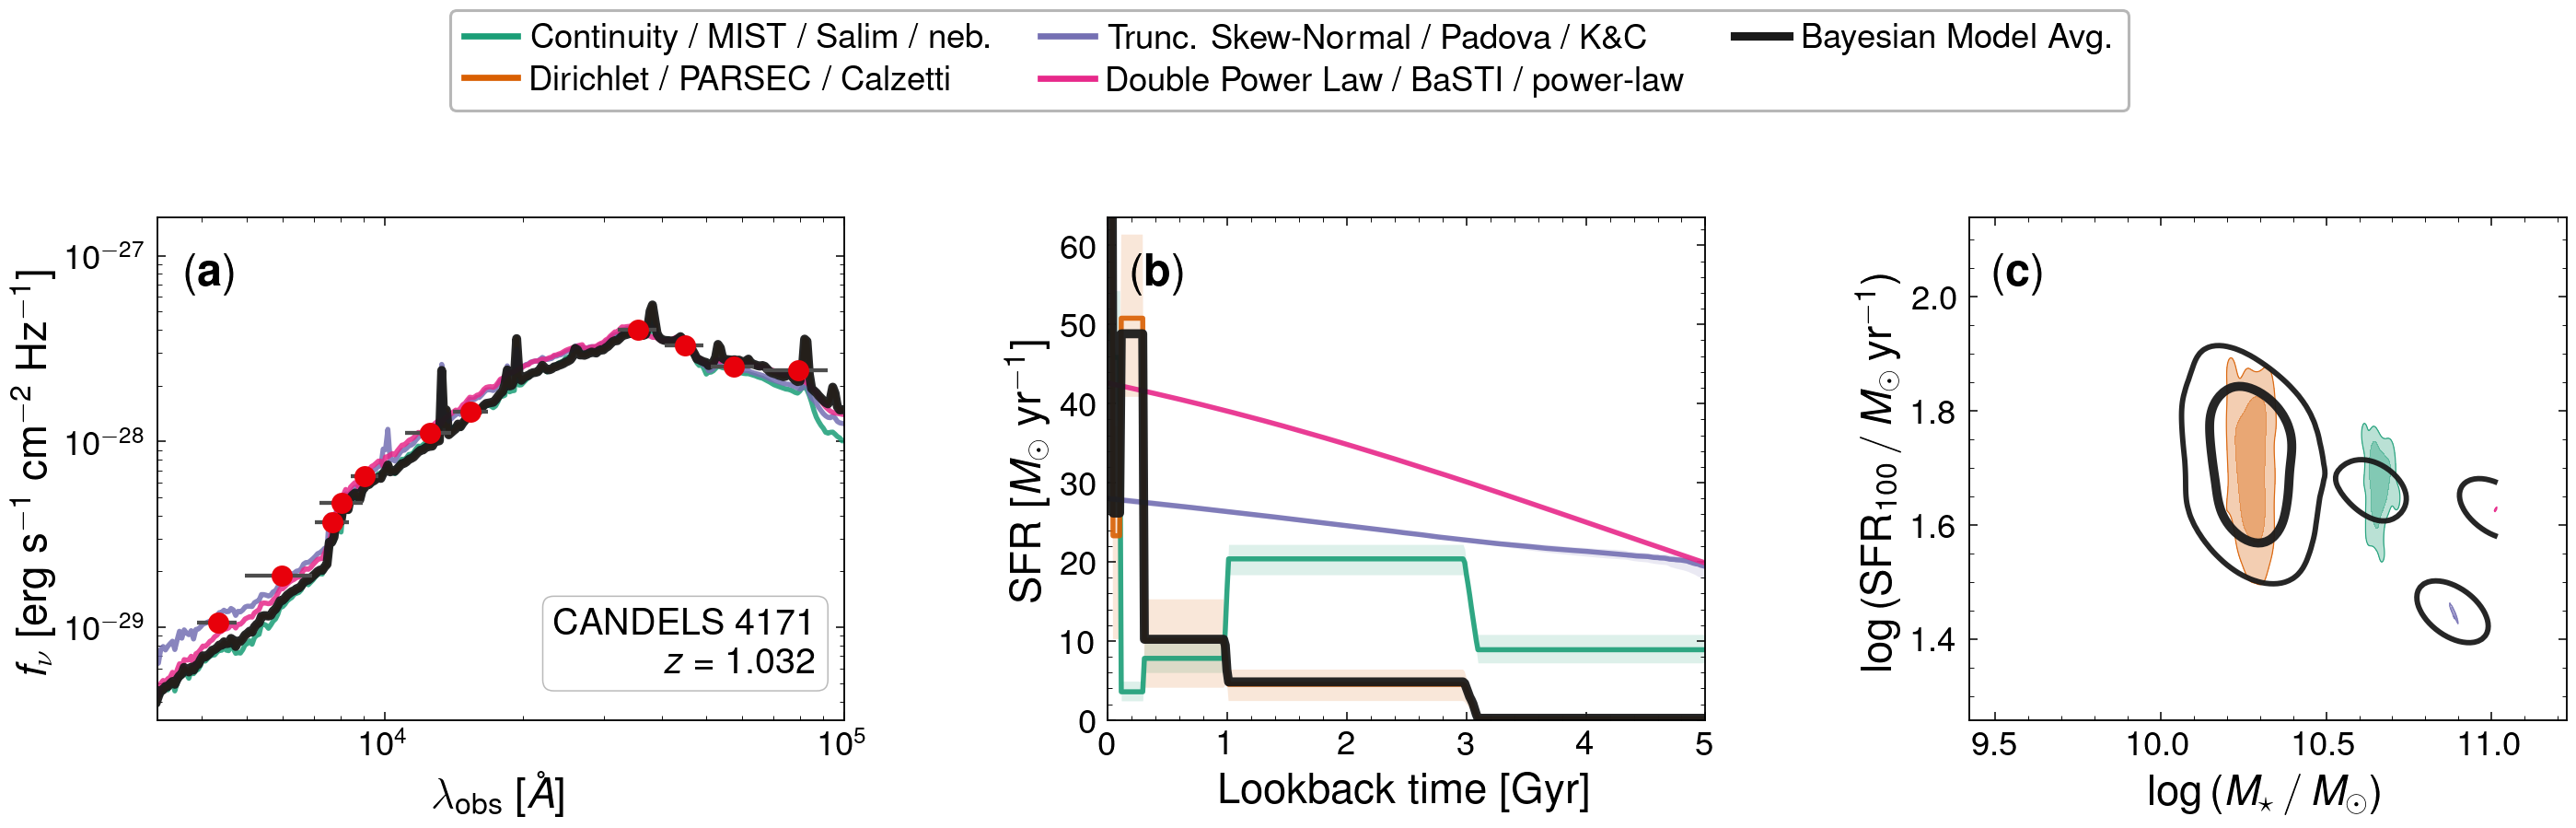

CANDELS 4171: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


In [11]:
plot_galaxy(4171)

In [12]:
show_timings(4171)

CANDELS 4171  (z = 1.032, 11 bands)
  build (4 models, incl. precompute publish + first compile):   0.8 s
  configuration                       D  fit [s]     log Z
  Continuity / MIST / Salim / neb.   10     48.0    -127.8
  Dirichlet / PARSEC / Calzetti      10     43.9     -88.8
  Trunc. Skew-Normal / Padova / K\&C  8     46.9    -544.4
  Double Power Law / BaSTI / power-law  6     36.4    -922.2
  4-config threaded wall-clock              48.0   (vs 175.1s summed)


### CANDELS 17418

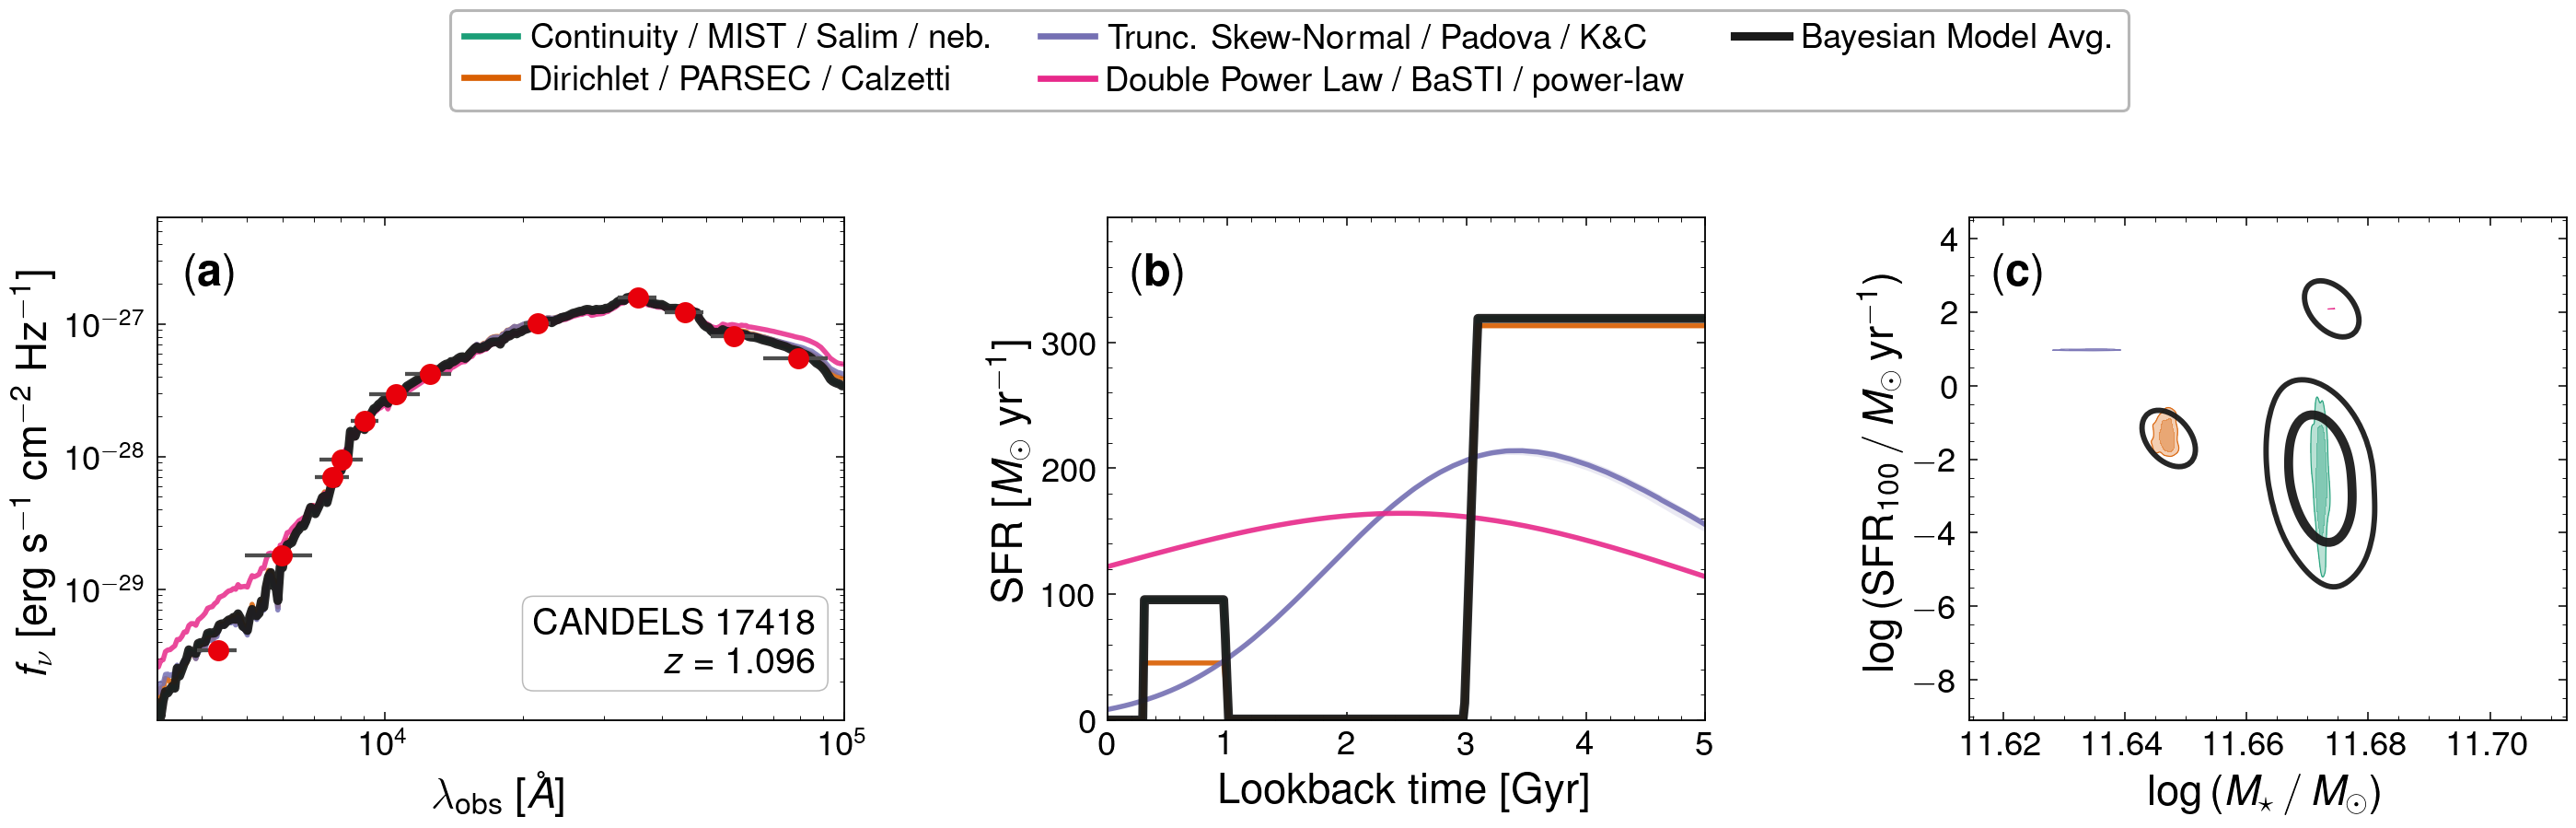

CANDELS 17418: BMA weights  A=1.00  B=0.00  C=0.00  D=0.00


In [13]:
plot_galaxy(17418)

In [14]:
show_timings(17418)

CANDELS 17418  (z = 1.096, 12 bands)
  build (4 models, incl. precompute publish + first compile):   0.2 s
  configuration                       D  fit [s]     log Z
  Continuity / MIST / Salim / neb.   10     33.3   -1718.0
  Dirichlet / PARSEC / Calzetti      10     46.3   -2867.7
  Trunc. Skew-Normal / Padova / K\&C  8     27.3   -3430.8
  Double Power Law / BaSTI / power-law  6     21.8  -17552.7
  4-config threaded wall-clock              46.3   (vs 128.7s summed)


### CANDELS 16435

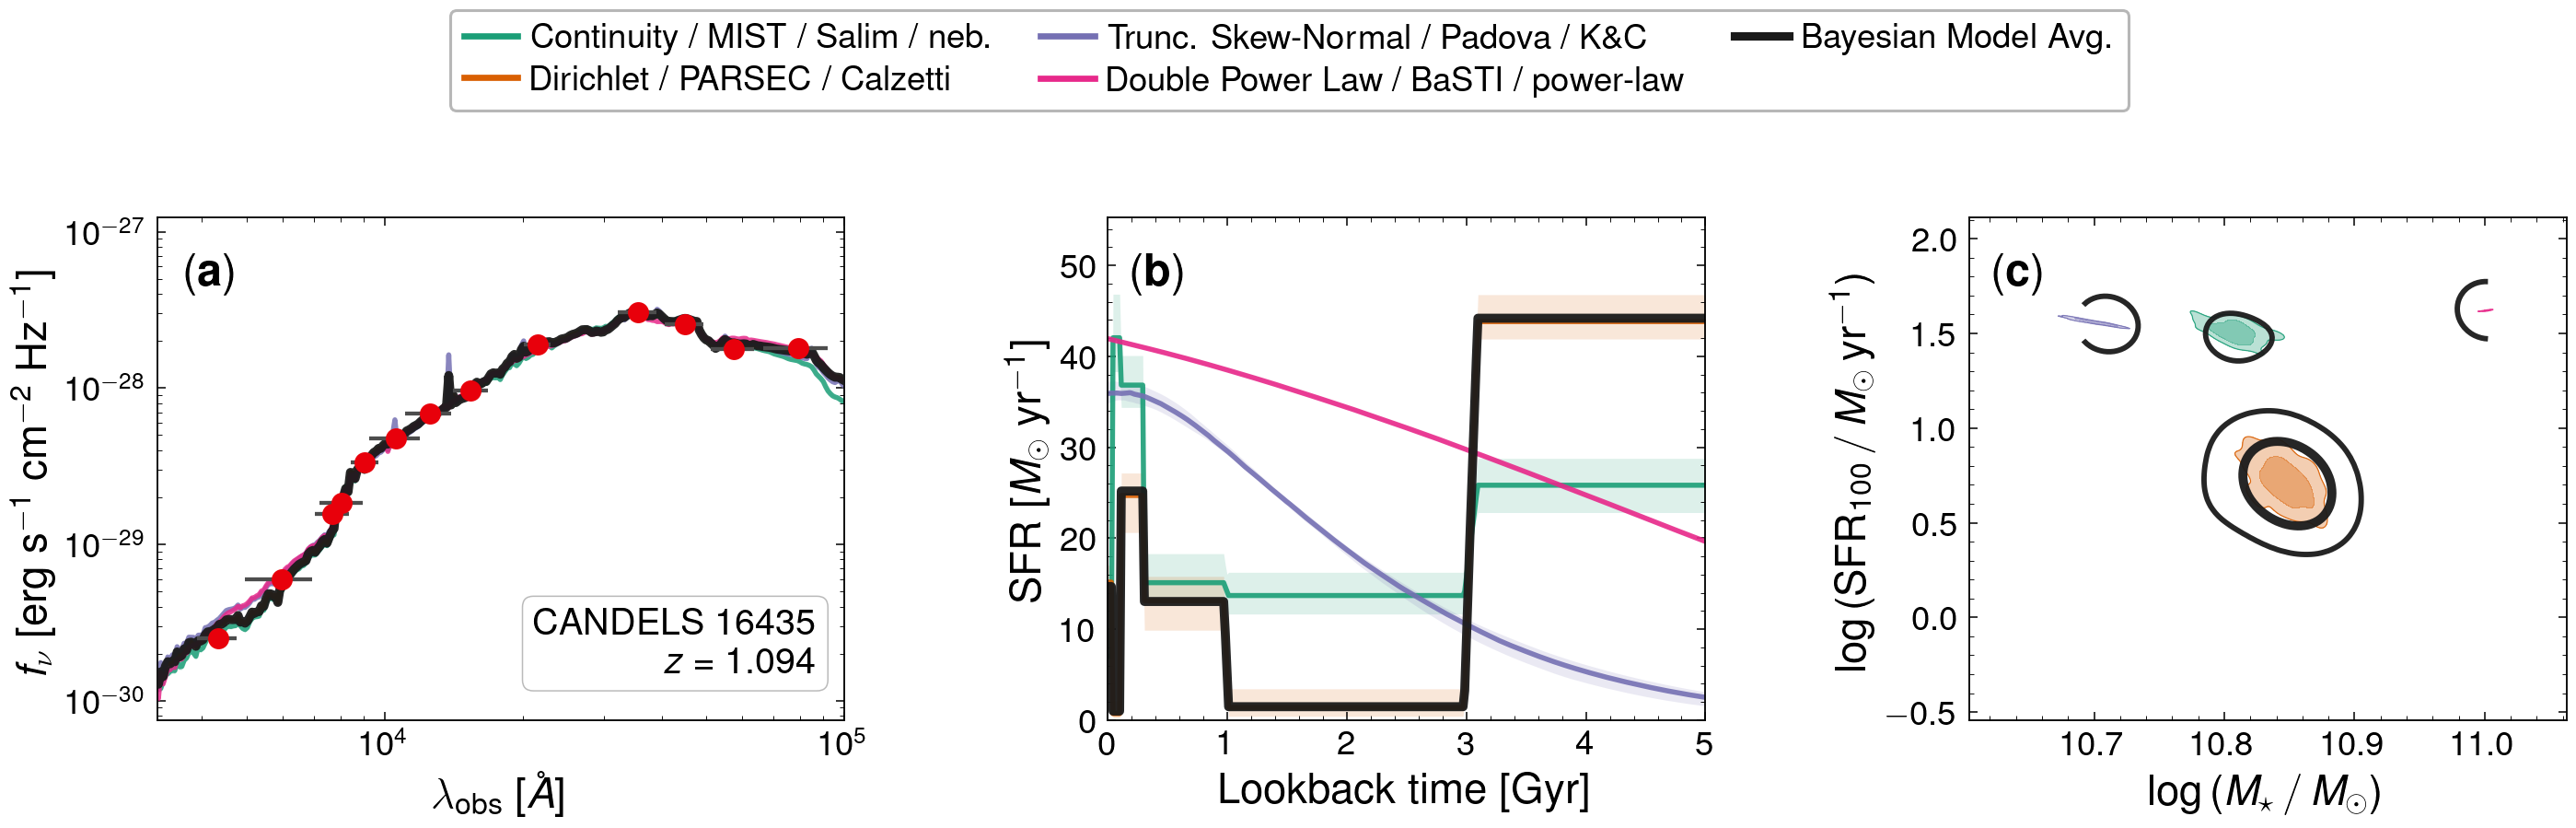

CANDELS 16435: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


In [15]:
plot_galaxy(16435)

In [16]:
show_timings(16435)

CANDELS 16435  (z = 1.094, 13 bands)
  build (4 models, incl. precompute publish + first compile):   0.2 s
  configuration                       D  fit [s]     log Z
  Continuity / MIST / Salim / neb.   10     22.6    -239.5
  Dirichlet / PARSEC / Calzetti      10     44.2    -209.7
  Trunc. Skew-Normal / Padova / K\&C  8     27.4    -414.0
  Double Power Law / BaSTI / power-law  6     17.3    -788.9
  4-config threaded wall-clock              44.2   (vs 111.5s summed)


### CANDELS 16514

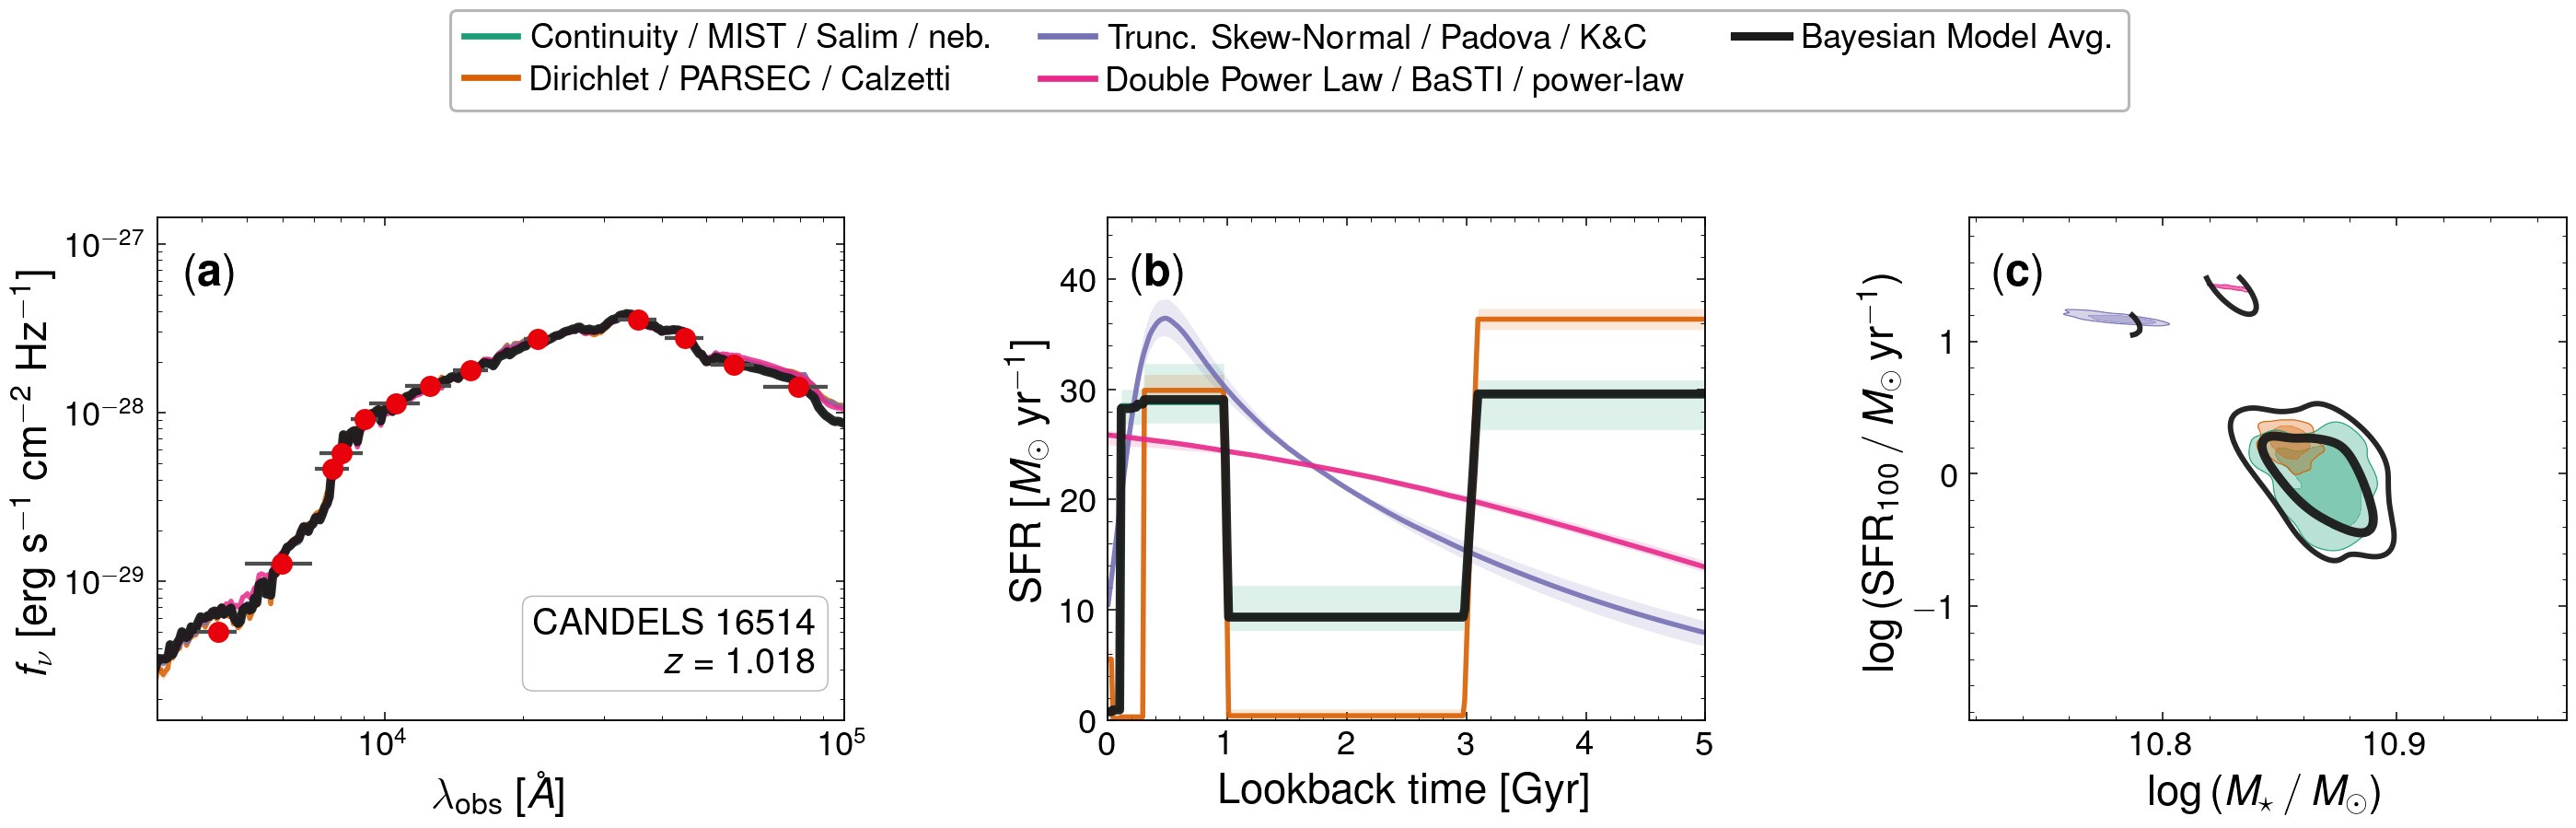

CANDELS 16514: BMA weights  A=1.00  B=0.00  C=0.00  D=0.00


In [17]:
plot_galaxy(16514)

In [18]:
show_timings(16514)

CANDELS 16514  (z = 1.018, 13 bands)
  build (4 models, incl. precompute publish + first compile):   0.2 s
  configuration                       D  fit [s]     log Z
  Continuity / MIST / Salim / neb.   10     24.6    -156.9
  Dirichlet / PARSEC / Calzetti      10     38.8    -180.3
  Trunc. Skew-Normal / Padova / K\&C  8     36.0    -343.0
  Double Power Law / BaSTI / power-law  6     14.6    -625.3
  4-config threaded wall-clock              38.8   (vs 114.0s summed)


### CANDELS 18160

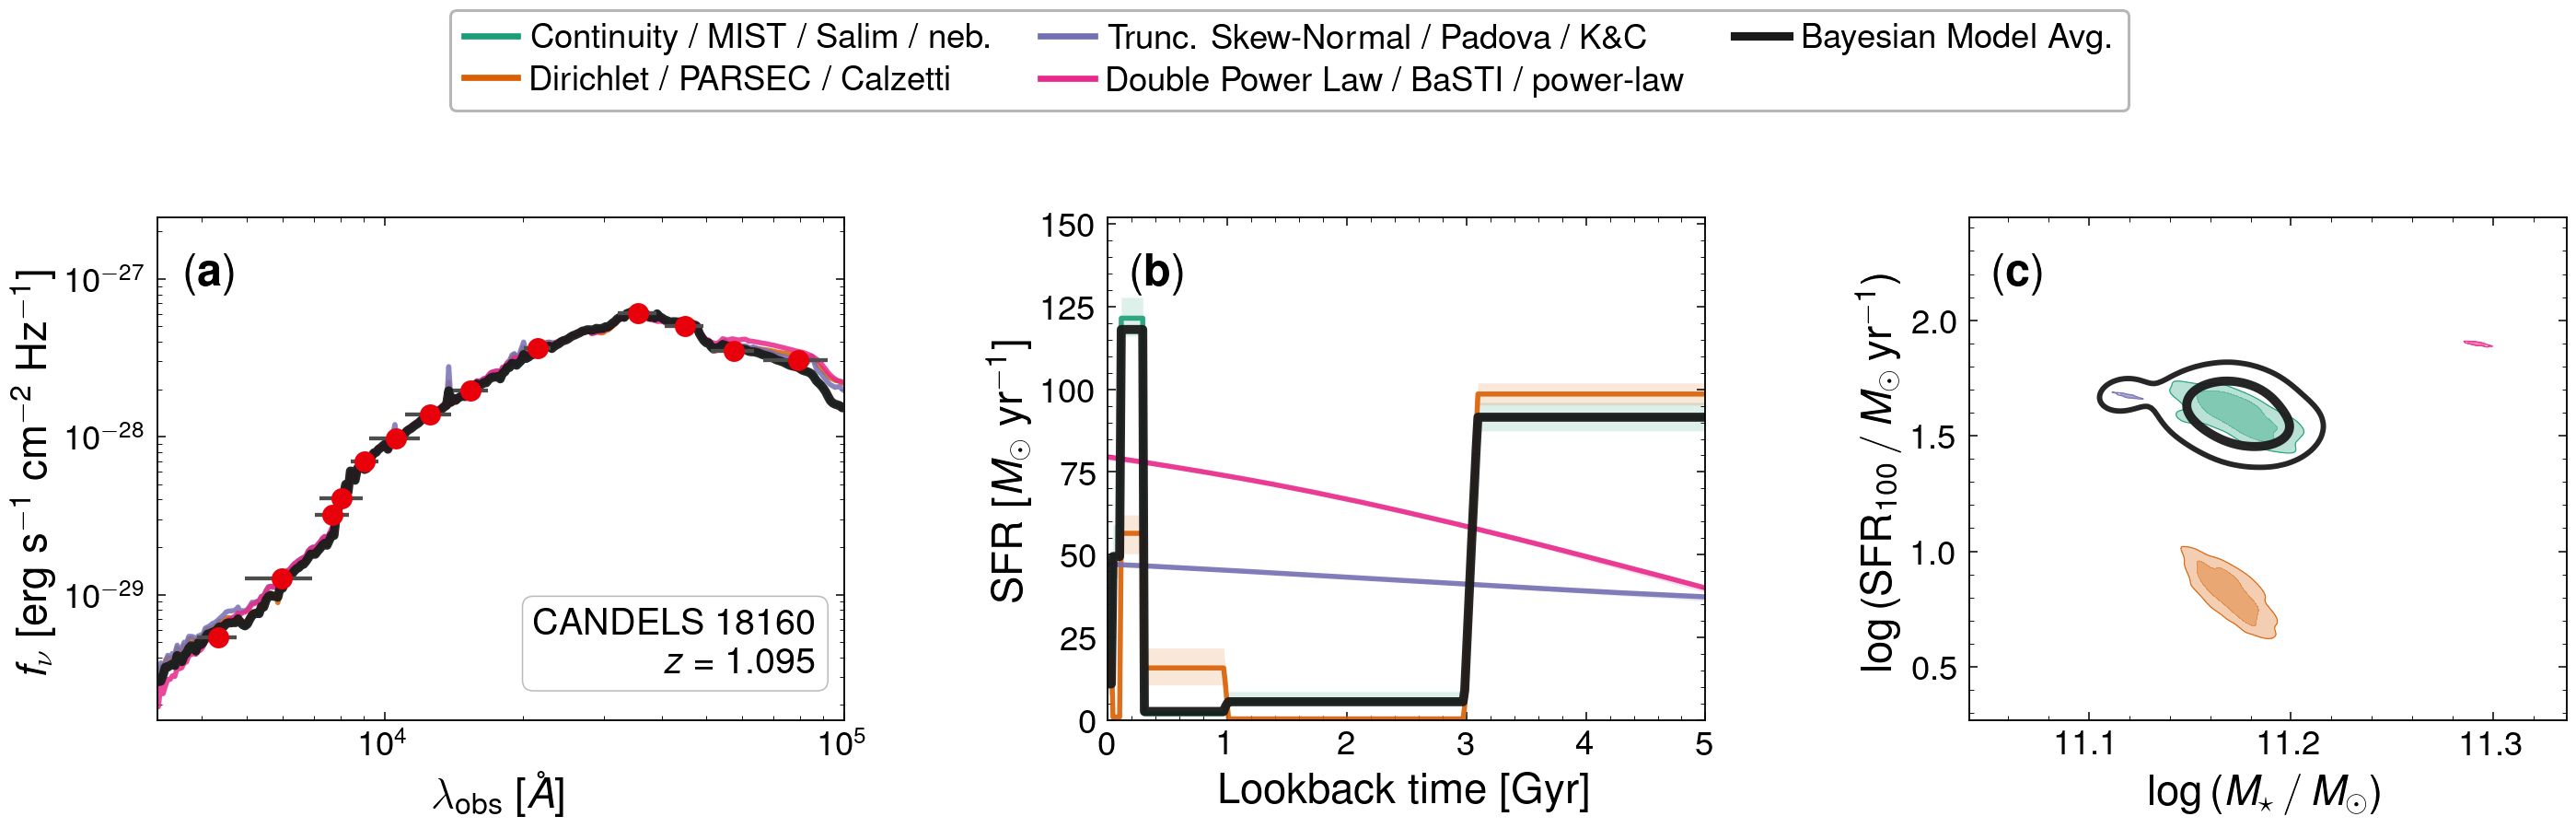

CANDELS 18160: BMA weights  A=1.00  B=0.00  C=0.00  D=0.00


In [19]:
plot_galaxy(18160)

In [20]:
show_timings(18160)

CANDELS 18160  (z = 1.095, 13 bands)
  build (4 models, incl. precompute publish + first compile):   0.2 s
  configuration                       D  fit [s]     log Z
  Continuity / MIST / Salim / neb.   10     31.3    -359.6
  Dirichlet / PARSEC / Calzetti      10     50.0    -623.9
  Trunc. Skew-Normal / Padova / K\&C  8     24.6    -736.1
  Double Power Law / BaSTI / power-law  6     14.6   -1007.5
  4-config threaded wall-clock              50.1   (vs 120.6s summed)


### CANDELS 15775

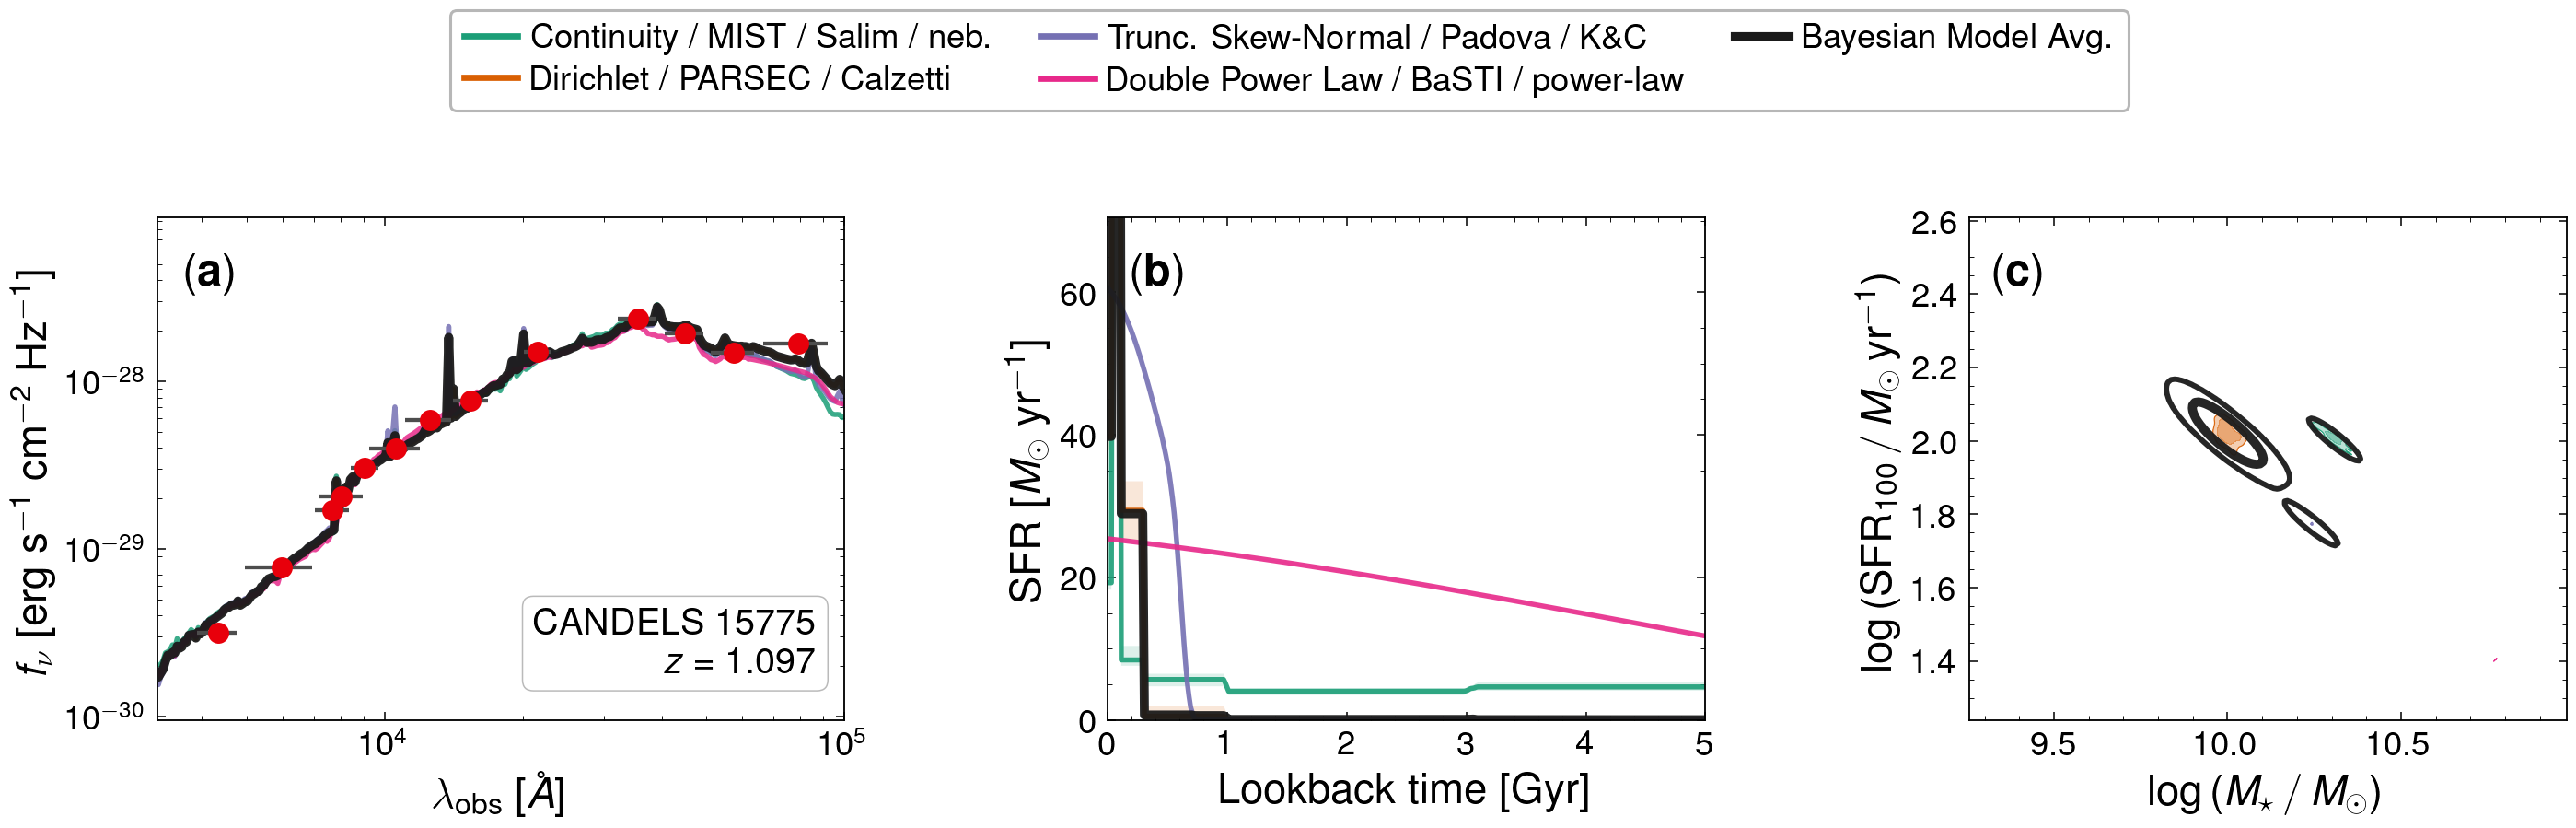

CANDELS 15775: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


In [21]:
plot_galaxy(15775)

In [22]:
show_timings(15775)

CANDELS 15775  (z = 1.097, 13 bands)
  build (4 models, incl. precompute publish + first compile):   0.2 s
  configuration                       D  fit [s]     log Z
  Continuity / MIST / Salim / neb.   10     22.4    -498.3
  Dirichlet / PARSEC / Calzetti      10     23.0    -354.8
  Trunc. Skew-Normal / Padova / K\&C  8     48.1    -834.3
  Double Power Law / BaSTI / power-law  6     19.4   -3066.5
  4-config threaded wall-clock              48.1   (vs 112.9s summed)


### CANDELS 13097

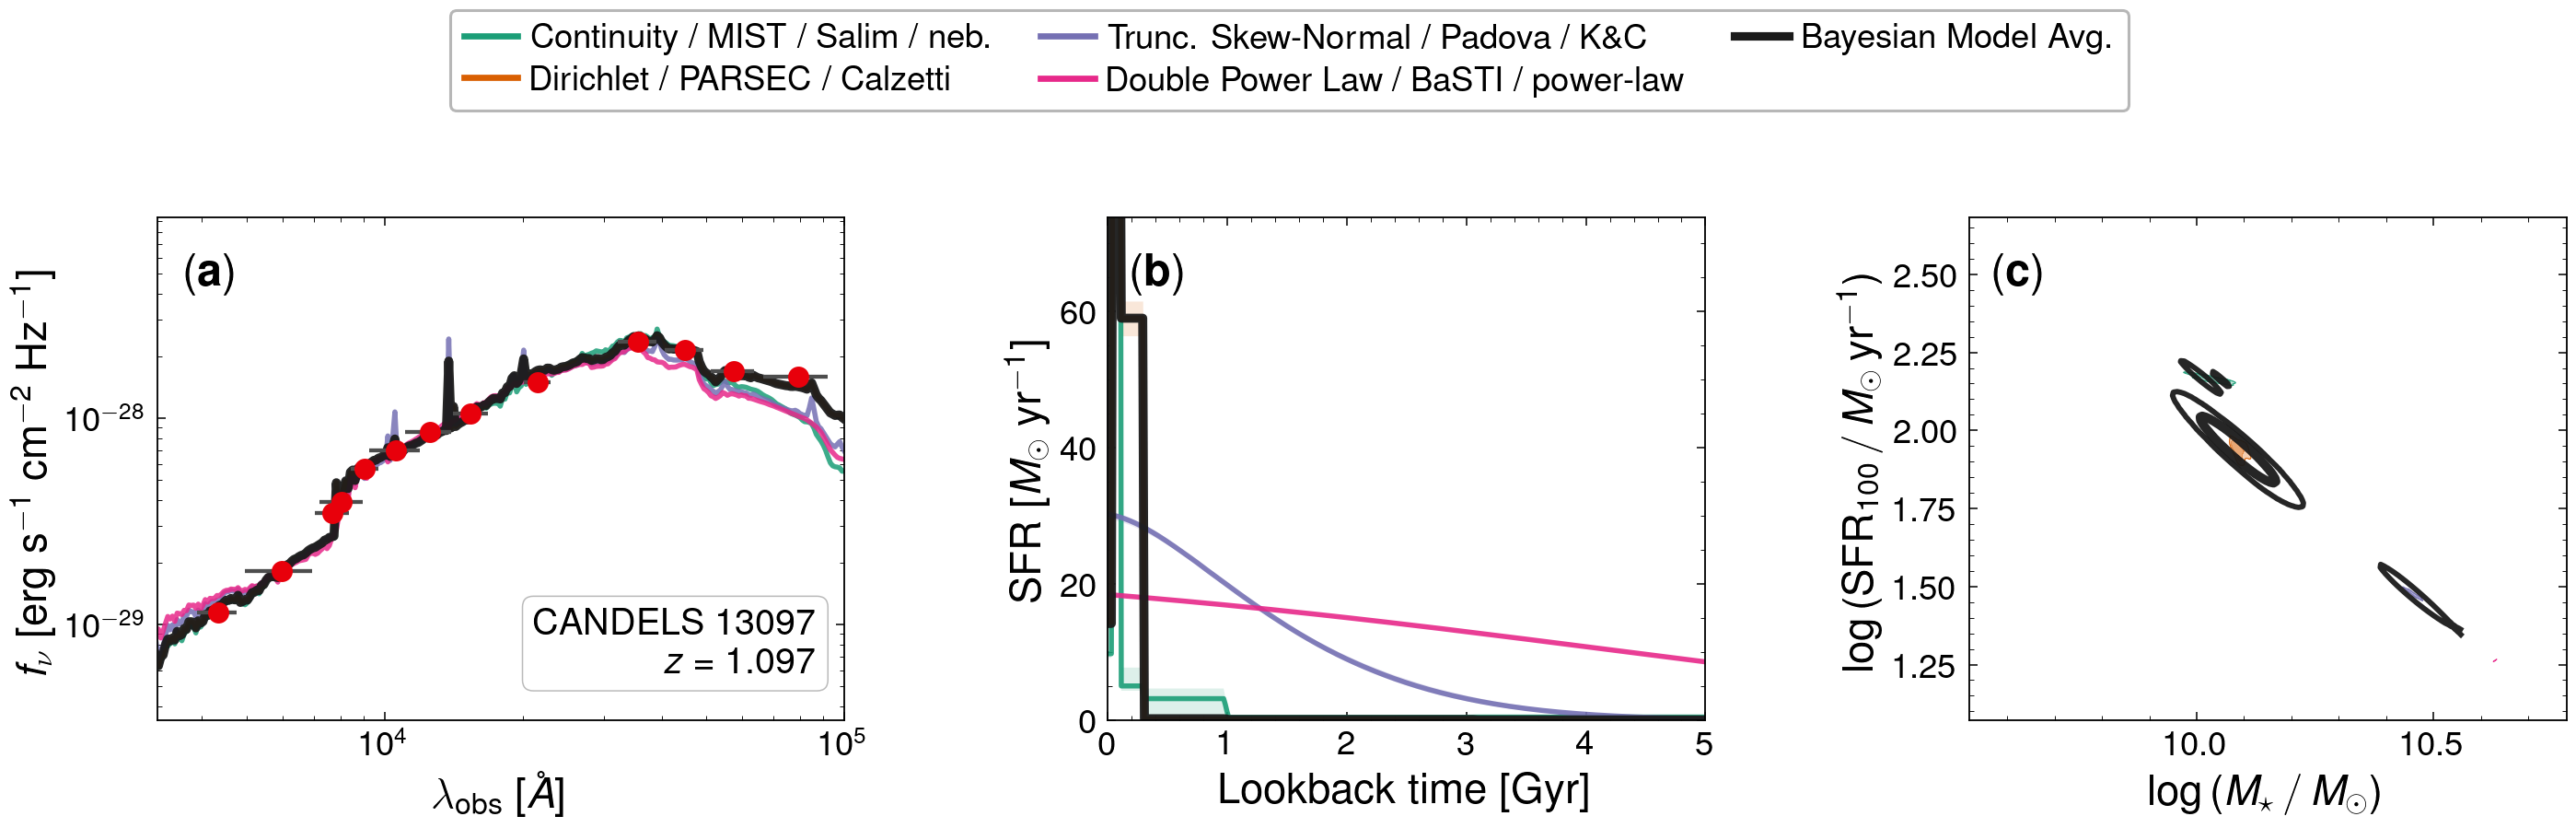

CANDELS 13097: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


In [23]:
plot_galaxy(13097)

In [24]:
show_timings(13097)

CANDELS 13097  (z = 1.097, 13 bands)
  build (4 models, incl. precompute publish + first compile):   0.2 s
  configuration                       D  fit [s]     log Z
  Continuity / MIST / Salim / neb.   10     25.3    -442.4
  Dirichlet / PARSEC / Calzetti      10     23.0    -257.4
  Trunc. Skew-Normal / Padova / K\&C  8     41.1   -2083.0
  Double Power Law / BaSTI / power-law  6     17.9   -4277.5
  4-config threaded wall-clock              41.1   (vs 107.4s summed)


## 9. Model averaging with an error floor

Every galaxy above collapses onto a single configuration: with the raw
catalog errors (~1-2% at this S/N) the evidence is decisive, so the BMA is
the single best model. This is correct, but it does not show what BMA is for.

Catalog errors are statistical only. They omit systematics (zero-points,
aperture matching, filter curves) and, more importantly for model comparison,
template imperfection: the SPS models are accurate to only a few percent. The
standard remedy (EAZY/FAST template errors plus a ~5% systematic, Prospector
noise inflation, CIGALE per-band floors) is to add a fractional error floor in
quadrature to the uncertainty that enters the likelihood,

$$\sigma_\mathrm{eff}^2 = \sigma_\mathrm{cat}^2 + (f_\mathrm{floor}\,f_\nu)^2 .$$

With a 10% floor the per-band $\chi^2$ no longer explodes, the evidences become
comparable, and the BMA spreads its weight across configurations. The cost is
broader, more overlapping $M_\star$-SFR contours, which is the honest
uncertainty once template error is included.

In [25]:
ERROR_FLOOR = 0.10  # 10% systematic + template-error floor, added in quadrature
FLOOR_IDS = [18160, 17418]  # picked (by a weight-entropy screen) to show real averaging
galaxies_floor = {}
for gal_idx in [int(np.where(ids == g)[0][0]) for g in FLOOR_IDS]:
    gal_id, z, names, fnu, sigma_cat = extract_photometry(gal_idx)
    sigma = jnp.sqrt(sigma_cat**2 + (ERROR_FLOOR * fnu) ** 2)  # inflated uncertainty
    obs = Observation(photometry=Photometry.from_names(names))
    models = build_configs(z, obs)
    posteriors = {}
    with ThreadPoolExecutor(max_workers=len(CONFIG_ORDER)) as ex:
        futs = [
            ex.submit(fit_one, models[cfg], fnu, sigma, gal_id=gal_id, cfg=cfg, salt="floor")
            for cfg in CONFIG_ORDER
        ]
        for fut in futs:
            cfg, post, _dt = fut.result()
            posteriors[cfg] = post
    g = dict(z=z, names=names, fnu=np.asarray(fnu), sigma=np.asarray(sigma),
             models=models, posteriors=posteriors, build_s=0.0,
             fit_timings={c: 0.0 for c in CONFIG_ORDER})  # fmt: skip
    g["weights"] = bma_weights(posteriors)
    g["spec"], g["sfh"], g["props"] = collect_predictions(g)
    galaxies_floor[gal_id] = g
    wstr = "  ".join(f"{c}={x:.2f}" for c, x in zip(CONFIG_ORDER, g["weights"]))
    print(f"CANDELS {gal_id} (floor {ERROR_FLOOR:.0%}):  BMA weights  {wstr}")

CANDELS 18160 (floor 10%):  BMA weights  A=0.13  B=0.00  C=0.34  D=0.53


CANDELS 17418 (floor 10%):  BMA weights  A=0.63  B=0.00  C=0.37  D=0.00


### CANDELS 18160 — 10% error floor (BMA averages four configurations)

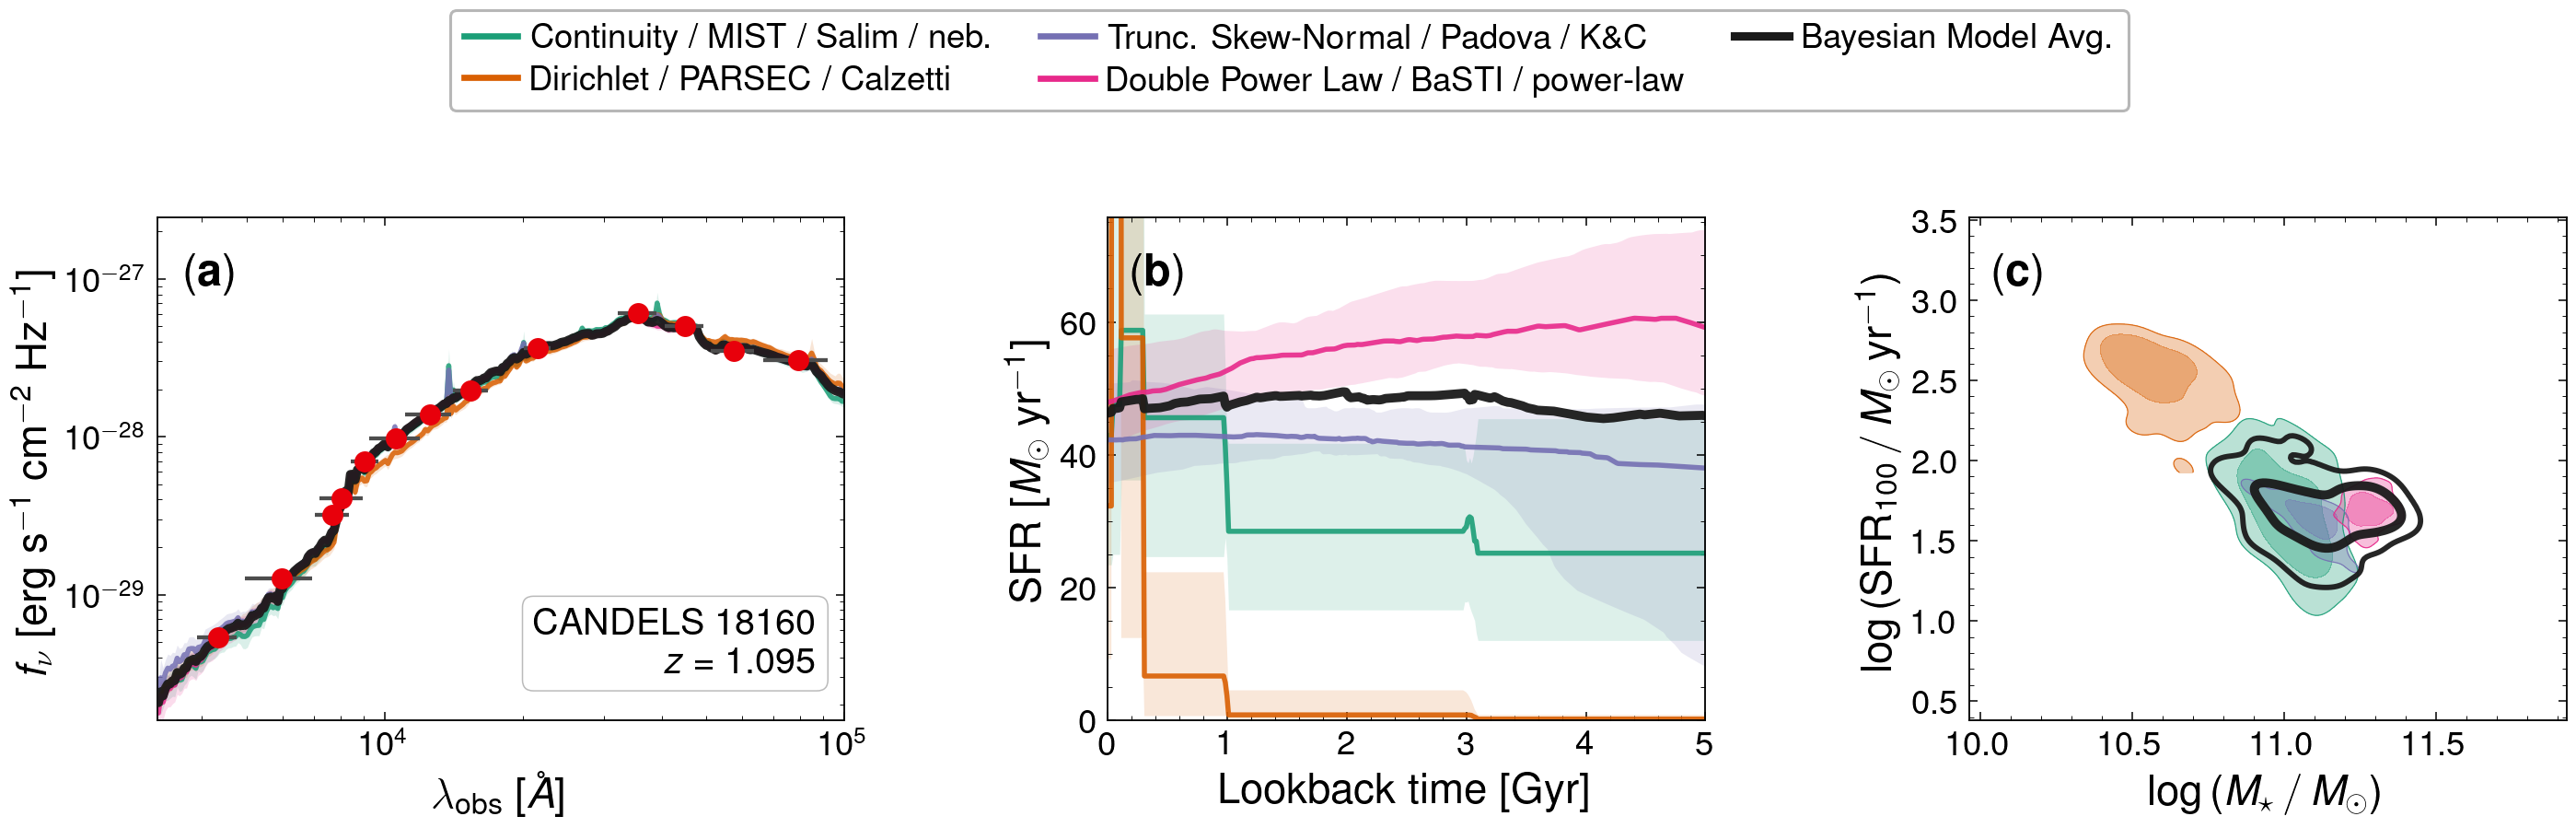

CANDELS 18160: BMA weights  A=0.13  B=0.00  C=0.34  D=0.53


In [26]:
plot_galaxy(18160, source=galaxies_floor, tag="_floor")

### CANDELS 17418 — 10% error floor (BMA averages three configurations)

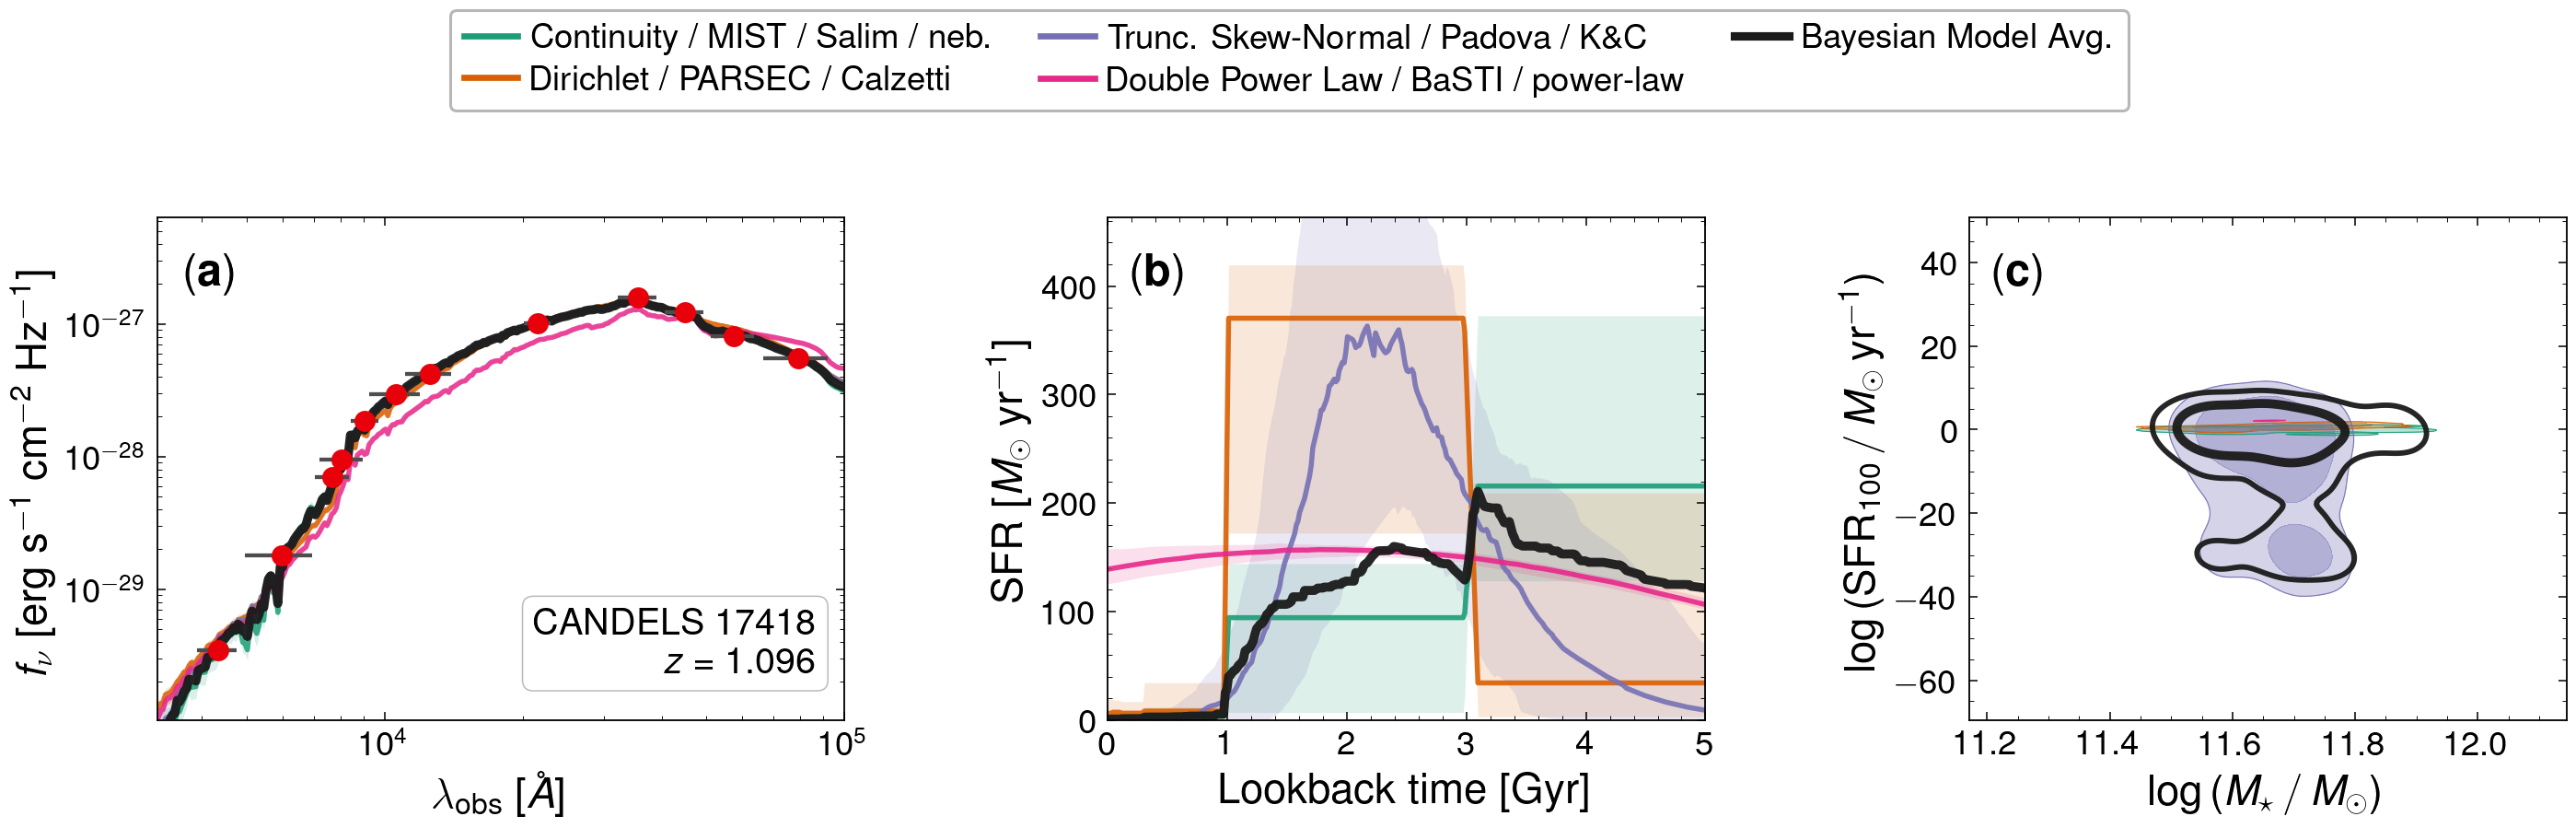

CANDELS 17418: BMA weights  A=0.63  B=0.00  C=0.37  D=0.00


In [27]:
plot_galaxy(17418, source=galaxies_floor, tag="_floor")

## 10. Summary

- The BMA weights are rarely uniform. One or two configurations usually
  dominate $\log Z$, and the average is pulled toward them while keeping some of
  the others' spread.
- The configurations disagree. Panel (c) shows four tight but separated
  $M_\star$-SFR clusters: changing the SSP library, SFH family, or dust law
  shifts the inferred stellar mass by a few tenths of a dex at fixed
  photometry. BMA makes that systematic spread explicit.
- Everything runs through the public API. Each model comes from
  `SEDModel.build(...)`, the speed path is `approx=WavePrecomp()`, and inference
  is `model.fit(data, noise, method="nss", ...)`, whose `log_evidence`
  supplies the averaging weights.
- The error budget decides whether averaging matters. With raw catalog errors
  the evidence collapses onto one model; a realistic ~10% floor (§9) makes the
  evidences comparable and the BMA averages. Whether to average or to trust the
  single best model depends on how well the photometry and templates are known,
  not on the fitter.